# 📊 What Makes a TV Series Popular?
### Student Data Lab (IMDb + Netflix + TMDb)

You will analyze real TV series data to discover what makes shows popular.

In [1]:
!make init
!python -m netflix.fetch
!python -m netflix.build

Initializing local development environment. This will verify and set up your
Python virtual environment, install all 3rd-party package requirements.
This may take a few minutes...


Initialization complete!
make python-init
Initializing Python virtual environment and installing dependencies. This may take a few minutes...
rm -r -f venv && \
	mkdir -p .pypi_cache && \
	make check-python

Verifying that Python python3.13 is installed ...

make python-clean && \
	npm install && \
	python3.13 -m venv venv && \
	source venv/bin/activate && \
	python3.13 -m pip install pip==25.3 setuptools wheel pip-tools && \
	PIP_CACHE_DIR=.pypi_cache python3.13 -m pip install -r requirements/local.txt

Cleaning Python virtual environment and __pycache__ directories ...

rm -rf venv
find ./netflix/ -name __pycache__ -type d -exec rm -rf {} +
⠙⠹⠸
up to date, audited 471 packages in 428ms
⠸
⠸101 packages are looking for funding
⠸  run `npm fund` for details
⠸
found 0 vulnerabilities
⠸Collecting pip==25.3
  U

In [2]:

import pandas as pd

imdb = pd.read_csv("netflix/data/imdb.titles.composite.csv")
netflix = pd.read_csv("netflix/data/netflix.titles.composite.csv")
tmdb = pd.read_csv("netflix/data/tmdb.titles.v3.csv")

print(imdb.shape, netflix.shape, tmdb.shape)


(299097, 15) (691, 13) (168639, 29)


## Exercise 1 — First Look at Popularity
Find the top shows in each dataset.

In [3]:

# Top Netflix shows by viewing hours
netflix.sort_values("netflix_viewing_hours", ascending=False).head(10)


,key,netflix_viewing_hours,netflix_weeks,netflix_year_hint,netflix_title,netflix_clean_title,tmdb_title,tmdb_popularity,tmdb_vote_average,tmdb_vote_count,imdb_title,imdb_averageRating,imdb_numVotes
661,st_th,2874260000,13,2022,Stranger Things,stranger things,Stranger Things,185.711,8.624,16161.0,Stranger Things,NaN,NaN
396,ga_sq,2289500000,20,2021,Squid Game,squid game,Squid Game,115.587,7.831,13053.0,Squid Game!,NaN,NaN
549,ma,1446260000,16,2021,Manifest,manifest,Manifest,111.411,7.728,1312.0,Manifest,NaN,NaN
447,he_mo,1170200000,14,2021,Money Heist,money heist,Money Heist,96.354,8.257,17836.0,Money Heist,8.2,612436.0
167,br,1108800000,11,2021,Bridgerton,bridgerton,Bridgerton,71.308,8.143,2045.0,Bridgerton,4.1,57.0
103,ar_ca_co,793740000,25,2022,Café con aroma de mujer,caf con aroma de mujer,Café con Aroma de Mujer,20.710,7.500,382.0,Café con aroma de mujer,8.6,106.0
690,yo,777480000,8,2021,You,you,続・アタッカーYOU 金メダルへの道,7.101,2.500,2.0,You,NaN,NaN
686,wi,757350000,6,2021,Windfall,windfall,Windfall,3.813,0.000,0.0,Windfall,NaN,NaN
607,oz,751600000,13,2022,Ozark,ozark,Ozark,68.006,8.244,1968.0,Ozark,8.4,394904.0
69,al_ar_us,659510000,11,2022,All of Us Are Dead,all of us are dead,All of Us Are Dead,107.108,8.354,3335.0,All of Us Are Dead,7.6,92709.0


In [4]:

# Top IMDb shows by rating
imdb.sort_values("averageRating", ascending=False).head(10)


,tconst,titleType,primaryTitle,originalTitle,startYear,endYear,runtimeMinutes,genres,title_key,averageRating,numVotes,all_akas,cast,directors,writers
113321,tt24228604,tvSeries,OdBita Pot,OdBita Pot,2022,2026,\N,Adventure,dita ot,9.8,1344.0,odbita pot,Anze Sever | Bit Sever,nm7689797,nm7689797
10372,tt41956044,tvSeries,D&D: Dungeon Masters,D&D: Dungeon Masters,2026,\N,\N,"Fantasy,Horror,Reality-TV",ungeon asters,9.8,115.0,d&d: dungeon masters,Mayanna Berrin | Devora Wilde | Neil Newbon | ...,nm0671741,\N
127839,tt28305644,tvSeries,EDP Watch,EDP Watch,2023,\N,\N,Crime,atch,9.7,106.0,edp watch,Alex Rosen | Skeeter Jean | Demarcus Cousins I...,nm15017595,nm15017595
263196,tt12831434,tvSeries,The Simonetta Lein Show,The Simonetta Lein Show,2020,2026,\N,Talk-Show,he imonetta ein how,9.7,810.0,the simonetta lein show,Gabriela Gonzalez | Kevin Harrington | Julian ...,\N,\N
164455,tt34929415,tvSeries,A Dog and a Plane,A Dog and a Plane,2026,\N,\N,"Comedy,Romance",og and a lane,9.7,551.0,a dog and a plane,Oabnithi Wiwattanawarang | Pompam Niti Chaichi...,nm8797158,\N
156259,tt33131139,tvSeries,Symposium,Symposium,2023,\N,\N,Talk-Show,ymposium,9.6,127.0,symposium,Niko Svanidze,nm16438483,nm16438483
59321,tt8088236,tvSeries,Geografens testamente,Geografens testamente,2011,2023,28,"Adventure,History",eografens testamente,9.6,1143.0,the geographers last will | geografens testamente,Judith Buchan | Lena Granhagen | Lakshman Mend...,nm1072502,"nm1072502,nm2050223,nm6813238"
63437,tt8560994,tvSeries,Friday Five Sharp,Friday Five Sharp,2015,\N,\N,Comedy,riday ive harp,9.6,4589.0,petak pet | friday five sharp,Kitodar Todorov | Tedi Dinh | Vladislav Petrov...,nm5663366,"nm5663366,nm11544010,nm1242398,nm9909867"
59344,tt8103440,tvSeries,Herne Katha,Herne Katha,2018,\N,\N,"Documentary,Short",erne atha,9.6,413.0,herne katha,Kamal Kumar | Bidhya Chapagain,"nm9678594,nm9678593","nm9678593,nm9678594"
36797,tt5961444,tvSeries,Upanishad Ganga,Upanishad Ganga,2012,2013,\N,"Drama,History,Short",panishad anga,9.6,1359.0,upanishad ganga,Rasika Dugal | Zakir Hussain | Sandeep Mohan |...,nm1363374,nm1363374


In [5]:

# Top TMDb shows by popularity
tmdb.sort_values("popularity", ascending=False).head(10)


,id,name,number_of_seasons,number_of_episodes,original_language,vote_count,vote_average,overview,adult,backdrop_path,...,tagline,genres,created_by,languages,networks,origin_country,spoken_languages,production_companies,production_countries,episode_run_time
1771,63770,The Late Show with Stephen Colbert,9,1419,en,205,6.495,Stephen Colbert brings his signature satire an...,False,/gMMnf8VRg3Z98WaFmOLr9Jk8pIs.jpg,...,NaN,"Comedy, Talk","Jon Stewart, Stephen Colbert, Tom Purcell, Chr...",en,CBS,US,English,"Spartina Productions, CBS Studios",United States of America,41
3035,215803,Batang Quiapo,2,178,tl,99,7.030,A young man rises to be one of the biggest out...,False,/jIV5weV19wH02rnuWyMtYI4dYC8.jpg,...,NaN,"Action & Adventure, Comedy, Drama",NaN,tl,"TV5, Kapamilya Channel",PH,NaN,"ABS-CBN Entertainment, Dreamscape Entertainmen...",Philippines,0
2285,94722,Tagesschau,72,20839,de,145,7.500,"German daily news program, the oldest still ex...",False,/jWXrQstj7p3Wl5MfYWY6IHqRpDb.jpg,...,NaN,News,NaN,de,ARD,DE,Deutsch,NDR,Germany,15
3593,14981,The Late Late Show with Craig Ferguson,11,2057,en,77,7.065,The Late Late Show with Craig Ferguson is an A...,False,/m0bV3qBiJBBlpFaaKjwHo13MVjm.jpg,...,NaN,"Comedy, Talk",NaN,en,CBS,US,English,NaN,United States of America,60
4565,2261,The Tonight Show Starring Johnny Carson,31,2924,en,51,7.800,The Tonight Show Starring Johnny Carson is a t...,False,/qFfWFwfaEHzDLWLuttWiYq7Poy2.jpg,...,NaN,Talk,"Steve Allen, Sylvester Weaver",en,NBC,US,English,"NBC Productions, Carson Productions",United States of America,60
4651,81329,Chronicles of the Sun,5,1252,fr,49,7.510,NaN,False,/rj3jBAZwPiOgkwAy1205MAgLahj.jpg,...,NaN,Soap,NaN,fr,France 2,FR,Français,"France Télévisions, Epeios Productions, France...",France,26
1600,59941,The Tonight Show Starring Jimmy Fallon,11,1233,en,234,6.038,After Jay Leno's second retirement from the pr...,False,/xl1wGwaPZInJo1JAnpKqnFozWBE.jpg,...,Tonight's just getting started.,"Comedy, Talk",Jimmy Fallon,en,NBC,US,English,"Broadway Video, Universal Television, Electric...",United States of America,45
7314,244643,El amor no tiene receta,1,91,es,23,8.300,"Paz Roble, a kind, hard-working and honest wom...",False,/bIhmqQNXcyWRzH153d3jaCbLTy3.jpg,...,NaN,"Action & Adventure, Family, Drama, Soap, Comed...","Juan Osorio Ortiz, Pablo Ferrer García-Travesí...",es,"Univision, Las Estrellas, ViX","MX, US",Español,"TelevisaUnivision Mexico, Televisa",Mexico,50
8641,225660,Pira-Pirasong Paraiso,2,78,tl,17,7.000,A con artist takes on the job of pretending to...,False,/2N4LXvTkUwPRkbvyzdmzvtnCHgR.jpg,...,NaN,NaN,NaN,"en, tl","TV5, Kapamilya Channel",PH,English,Dreamscape Entertainment Television,Philippines,0
7217,91759,Come Home Love: Lo and Behold,1,2107,cn,23,4.565,"Hung Sue Gan starting from the bottom, establi...",False,/ohJTnu93hJ0Uonl86Wn3mOSlWXN.jpg,...,NaN,"Family, Comedy, Drama",NaN,cn,TVB Jade,HK,广州话 / 廣州話,TVB,Hong Kong,22


## Exercise 2 — What Does “Popular” Mean?
Compare different popularity signals.

In [6]:

netflix["netflix_viewing_hours"].describe()


count    6.910000e+02
mean     6.919165e+07
std      1.879555e+08
min      1.130000e+06
25%      8.930000e+06
50%      2.028000e+07
75%      5.560000e+07
max      2.874260e+09
Name: netflix_viewing_hours, dtype: float64

In [7]:

imdb["averageRating"].describe()


count    48167.000000
mean         6.851699
std          1.293658
min          1.000000
25%          6.300000
50%          7.100000
75%          7.700000
max          9.800000
Name: averageRating, dtype: float64

In [8]:

tmdb["popularity"].describe()


count    168639.000000
mean          5.882644
std          42.023216
min           0.000000
25%           0.600000
50%           0.857000
75%           2.431500
max        3707.008000
Name: popularity, dtype: float64

## Exercise 3 — High Views vs High Ratings

In [9]:

netflix.sort_values("netflix_viewing_hours", ascending=False).head(5)[["netflix_title","netflix_viewing_hours"]]


,netflix_title,netflix_viewing_hours
661,Stranger Things,2874260000
396,Squid Game,2289500000
549,Manifest,1446260000
447,Money Heist,1170200000
167,Bridgerton,1108800000


## Exercise 4 — Genre Power

In [10]:

imdb["genres"].dropna().head()


0    Crime,Drama
1    Documentary
2         Comedy
3     Reality-TV
4     Reality-TV
Name: genres, dtype: object

## Exercise 5 — Language & Global Reach

In [11]:

tmdb["original_language"].value_counts().head(10)


original_language
en    76304
zh    14422
ja    14048
ko     7820
de     7712
fr     7290
es     5602
pt     3551
ru     2963
nl     2923
Name: count, dtype: int64

## Exercise 6 — Short vs Long Shows

In [12]:

tmdb[["number_of_seasons","popularity"]].corr()


,number_of_seasons,popularity
number_of_seasons,1.000000,0.189827
popularity,0.189827,1.000000


## Exercise 7 — Binge Effect

In [13]:

netflix[["netflix_weeks","netflix_viewing_hours"]].corr()


,netflix_weeks,netflix_viewing_hours
netflix_weeks,1.000000,0.634786
netflix_viewing_hours,0.634786,1.000000


## Exercise 8 — Cast Impact

In [14]:

imdb["cast_count"] = imdb["cast"].fillna("").apply(lambda x: len(x.split("|")))
imdb[["cast_count","averageRating"]].corr()


,cast_count,averageRating
cast_count,1.00000,-0.07716
averageRating,-0.07716,1.00000


## Exercise 9 — The Perfect Show Profile

Write your ideal show recipe using evidence from the dataset.

## Exercise 10 — Build a Hit Score

In [15]:

df = netflix.copy()

df["hit_score"] = (
    df["netflix_viewing_hours"] / df["netflix_viewing_hours"].max()
)

df.sort_values("hit_score", ascending=False).head(10)


,key,netflix_viewing_hours,netflix_weeks,netflix_year_hint,netflix_title,netflix_clean_title,tmdb_title,tmdb_popularity,tmdb_vote_average,tmdb_vote_count,imdb_title,imdb_averageRating,imdb_numVotes,hit_score
661,st_th,2874260000,13,2022,Stranger Things,stranger things,Stranger Things,185.711,8.624,16161.0,Stranger Things,NaN,NaN,1.000000
396,ga_sq,2289500000,20,2021,Squid Game,squid game,Squid Game,115.587,7.831,13053.0,Squid Game!,NaN,NaN,0.796553
549,ma,1446260000,16,2021,Manifest,manifest,Manifest,111.411,7.728,1312.0,Manifest,NaN,NaN,0.503176
447,he_mo,1170200000,14,2021,Money Heist,money heist,Money Heist,96.354,8.257,17836.0,Money Heist,8.2,612436.0,0.407131
167,br,1108800000,11,2021,Bridgerton,bridgerton,Bridgerton,71.308,8.143,2045.0,Bridgerton,4.1,57.0,0.385769
103,ar_ca_co,793740000,25,2022,Café con aroma de mujer,caf con aroma de mujer,Café con Aroma de Mujer,20.710,7.500,382.0,Café con aroma de mujer,8.6,106.0,0.276155
690,yo,777480000,8,2021,You,you,続・アタッカーYOU 金メダルへの道,7.101,2.500,2.0,You,NaN,NaN,0.270497
686,wi,757350000,6,2021,Windfall,windfall,Windfall,3.813,0.000,0.0,Windfall,NaN,NaN,0.263494
607,oz,751600000,13,2022,Ozark,ozark,Ozark,68.006,8.244,1968.0,Ozark,8.4,394904.0,0.261493
69,al_ar_us,659510000,11,2022,All of Us Are Dead,all of us are dead,All of Us Are Dead,107.108,8.354,3335.0,All of Us Are Dead,7.6,92709.0,0.229454


## Bonus — Polti's 36 Dramatic Situations
Choose ONE situation from Polti's framework and design a TV series around it.

Explain how it could become a hit using dataset evidence.

## our analysis
口碑分數以及觀看時數關係

## our analysisy
資料表屬性總表

In [34]:
import pandas as pd

# 1. 載入你本地最原始的 composite 與 v3 資料集
# （這三個是你在前面步驟中讀取過的原始 DataFrame）
print("=" * 80)
print("🔍 原始資料集維度（Columns）與欄位身家調查")
print("=" * 80)

# ------------------------------------------
# A. Netflix 複合資料集 (包含已匹配的 IMDb 資訊)
# ------------------------------------------
print(f"\n📌 1. Netflix 複合資料表 (netflix.titles.composite) — 共 {netflix.shape[0]} 列, {netflix.shape[1]} 個欄位")
print("-" * 80)
# 建立一個清晰的欄位結構表
netflix_info = pd.DataFrame({
    "資料型態": netflix.dtypes,
    "非空值數量": netflix.notna().sum(),
    "缺失值數量": netflix.isna().sum(),
    "缺失值比例": (netflix.isna().mean() * 100).round(2).astype(str) + "%",
    "數值範例": netflix.iloc[0].values
})
display(netflix_info)

# ------------------------------------------
# B. TMDb 原始資料集 (tmdb.titles.v3)
# ------------------------------------------
print(f"\n📌 2. TMDb 原始資料表 (tmdb.titles.v3) — 共 {tmdb.shape[0]} 列, {tmdb.shape[1]} 個欄位")
print("-" * 80)
tmdb_info = pd.DataFrame({
    "資料型態": tmdb.dtypes,
    "非空值數量": tmdb.notna().sum(),
    "缺失值數量": tmdb.isna().sum(),
    "缺失值比例": (tmdb.isna().mean() * 100).round(2).astype(str) + "%",
    "數值範例": tmdb.iloc[0].values
})
display(tmdb_info)

# ------------------------------------------
# C. IMDb 原始資料集 (imdb.titles.composite)
# ------------------------------------------
print(f"\n📌 3. IMDb 原始資料表 (imdb.titles.composite) — 共 {imdb.shape[0]} 列, {imdb.shape[1]} 個欄位")
print("-" * 80)
imdb_info = pd.DataFrame({
    "資料型態": imdb.dtypes,
    "非空值數量": imdb.notna().sum(),
    "缺失值數量": imdb.isna().sum(),
    "缺失值比例": (imdb.isna().mean() * 100).round(2).astype(str) + "%",
    "數值範例": imdb.iloc[0].values
})
display(imdb_info)

🔍 原始資料集維度（Columns）與欄位身家調查

📌 1. Netflix 複合資料表 (netflix.titles.composite) — 共 691 列, 13 個欄位
--------------------------------------------------------------------------------


,資料型態,非空值數量,缺失值數量,缺失值比例,數值範例
key,object,691,0,0.0%,10
netflix_viewing_hours,int64,691,0,0.0%,26580000
netflix_weeks,int64,691,0,0.0%,2
netflix_year_hint,int64,691,0,0.0%,2021
netflix_title,object,691,0,0.0%,The 100
netflix_clean_title,object,690,1,0.14%,the 100
tmdb_title,object,394,297,42.98%,The 100
tmdb_popularity,float64,394,297,42.98%,127.224
tmdb_vote_average,float64,394,297,42.98%,7.916
tmdb_vote_count,float64,394,297,42.98%,7666.0



📌 2. TMDb 原始資料表 (tmdb.titles.v3) — 共 168639 列, 29 個欄位
--------------------------------------------------------------------------------


,資料型態,非空值數量,缺失值數量,缺失值比例,數值範例
id,int64,168639,0,0.0%,1399
name,object,168634,5,0.0%,Game of Thrones
number_of_seasons,int64,168639,0,0.0%,8
number_of_episodes,int64,168639,0,0.0%,73
original_language,object,168639,0,0.0%,en
vote_count,int64,168639,0,0.0%,21857
vote_average,float64,168639,0,0.0%,8.442
overview,object,93333,75306,44.66%,Seven noble families fight for control of the ...
adult,bool,168639,0,0.0%,False
backdrop_path,object,77780,90859,53.88%,/2OMB0ynKlyIenMJWI2Dy9IWT4c.jpg



📌 3. IMDb 原始資料表 (imdb.titles.composite) — 共 299097 列, 16 個欄位
--------------------------------------------------------------------------------


,資料型態,非空值數量,缺失值數量,缺失值比例,數值範例
tconst,object,299097,0,0.0%,tt38876090
titleType,object,299097,0,0.0%,tvSeries
primaryTitle,object,299096,1,0.0%,Gomorrah: The Origins
originalTitle,object,299096,1,0.0%,Gomorra: Le origini
startYear,object,299097,0,0.0%,2026
endYear,object,299097,0,0.0%,\N
runtimeMinutes,object,299097,0,0.0%,\N
genres,object,299097,0,0.0%,"Crime,Drama"
title_key,object,298121,976,0.33%,omorrah he rigins
averageRating,float64,48167,250930,83.9%,7.2


## our analysis
？？

Distribution diagnostics


,Variable,Count,Mean,Median,Skewness,95th percentile
0,TMDb popularity,168,3.874000e+01,14.63,7.73,1.285900e+02
1,Netflix viewing hours,168,1.112935e+08,34485000.00,3.28,5.236960e+08
2,Binge velocity,168,2.366224e+07,15963125.00,2.15,6.571730e+07
3,IMDb vote count,168,2.760432e+04,3927.50,6.16,9.204995e+04


,Stage,Titles,Coverage (%)
0,Netflix composite rows,691,100.0
1,Exact IMDb title match,640,92.6
2,Exact TMDb title match,293,42.4
3,Exact match to both,285,41.2
4,Narrative titles used,168,24.3


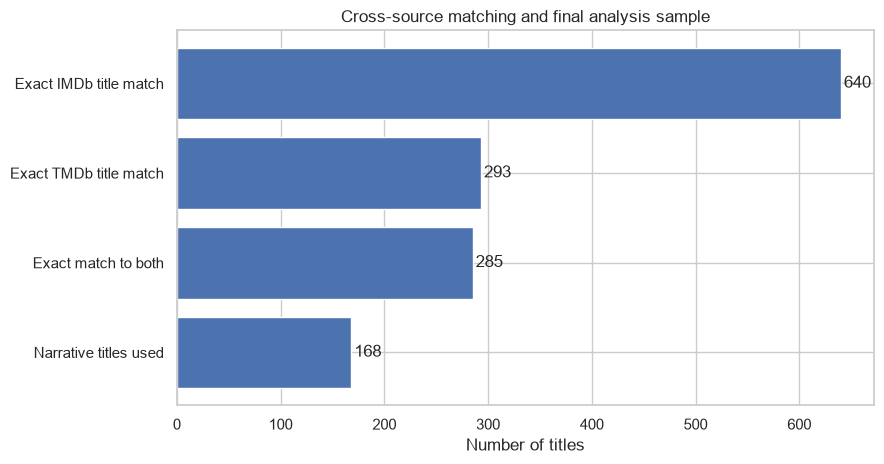

Genres require at least 8 matched titles.


,genre,title_count,median_quality,median_reach,median_intensity,median_staying,hit_rate,balanced_score
0,Action & Adventure,26,7.13,60.20,18448333.0,2.0,0.231,0.764
1,Drama,97,7.15,19.91,16970000.0,3.0,0.381,0.736
2,Comedy,31,7.13,21.83,17030000.0,2.0,0.194,0.653
3,Crime,36,7.01,19.05,18428333.0,2.5,0.333,0.556
4,Kids,8,7.17,20.68,12667500.0,2.0,0.125,0.514
5,Animation,19,7.11,50.65,14360000.0,2.0,0.000,0.514
6,Sci-Fi & Fantasy,23,7.11,29.84,13290000.0,2.0,0.304,0.486
7,Mystery,28,7.02,13.47,15423571.0,3.0,0.357,0.486
8,Documentary,19,6.82,5.59,16380000.0,2.0,0.053,0.292


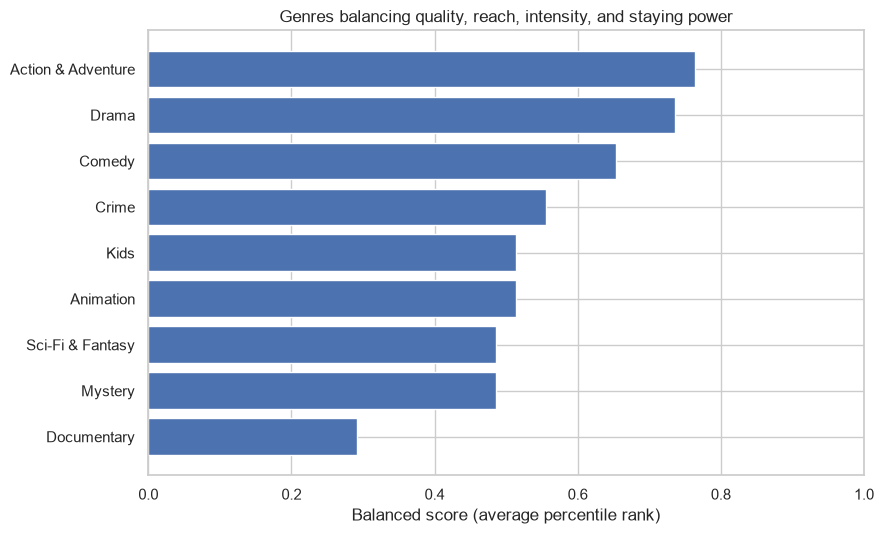

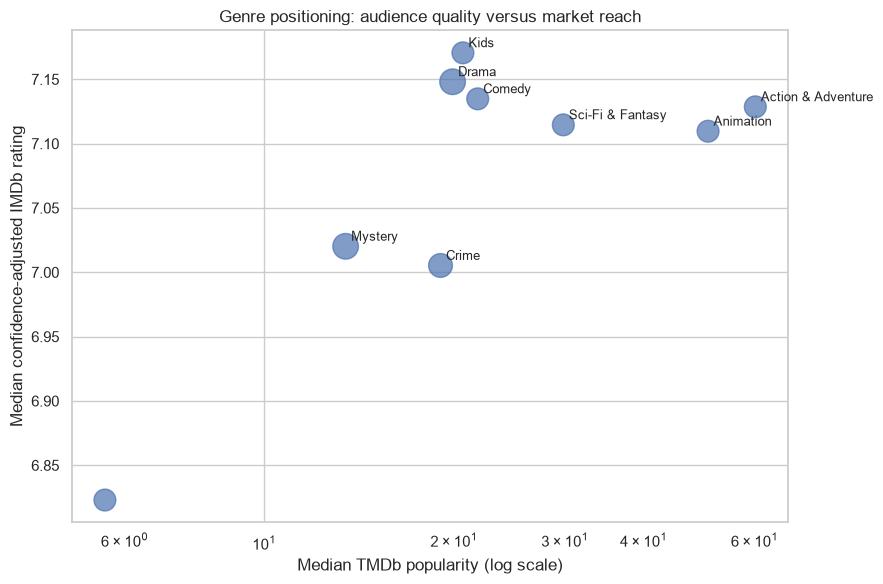

Conditional analysis within: Action & Adventure
Observed lifecycle profile


,season_plan,title_count,median_quality,median_reach,median_intensity,median_staying,hit_rate,median_quality_pct,median_reach_pct,median_intensity_pct,median_staying_pct,format_score
0,4+ seasons,7,7.164,82.890,37914000.0,2.0,0.429,1.000,1.000,1.000,0.667,0.917
1,1 season,10,7.117,24.664,18767500.0,2.0,0.100,0.667,0.333,0.667,0.667,0.583
2,2–3 seasons,9,7.009,69.980,17325000.0,2.0,0.222,0.333,0.667,0.333,0.667,0.500


Episodes per season


,episode_plan,title_count,median_quality,median_reach,median_intensity,median_staying,hit_rate,median_quality_pct,median_reach_pct,median_intensity_pct,median_staying_pct,format_score
0,≤8 episodes/season,8,7.216,29.980,33719000.0,4.0,0.50,0.667,0.333,1.000,1.0,0.750
1,9–12 episodes/season,8,7.217,42.363,23232500.0,2.0,0.25,1.000,0.667,0.667,0.5,0.708
2,13+ episodes/season,10,6.971,103.132,13825000.0,2.0,0.00,0.333,1.000,0.333,0.5,0.542


Viewing commitment per season


,commitment_group,title_count,median_quality,median_reach,median_intensity,median_staying,hit_rate,median_quality_pct,median_reach_pct,median_intensity_pct,median_staying_pct,format_score
0,Moderate (6–10 h),7,7.303,79.040,3.791400e+07,5.0,0.571,1.000,0.667,1.000,1.0,0.917
1,Compact (≤6 h),8,7.129,36.434,1.848583e+07,2.0,0.125,0.667,0.333,0.667,0.5,0.542
2,Long-form (>16 h),5,7.105,149.166,1.436000e+07,2.0,0.000,0.333,1.000,0.333,0.5,0.542


Language market


,language_market,title_count,median_quality,median_reach,median_intensity,median_staying,hit_rate,median_quality_pct,median_reach_pct,median_intensity_pct,median_staying_pct,format_score
0,English,12,7.174,45.146,28995000.0,2.0,0.333,1.0,0.5,1.0,0.75,0.812
1,Non-English,14,6.971,76.664,14340000.0,2.0,0.143,0.5,1.0,0.5,0.75,0.688


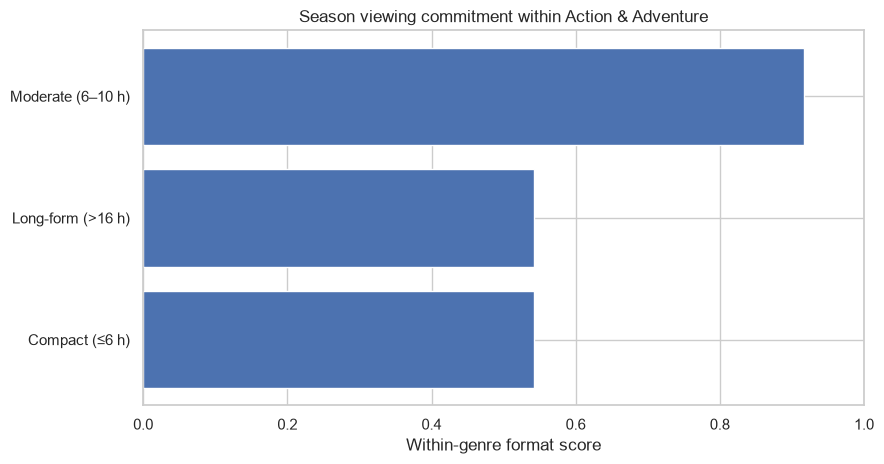

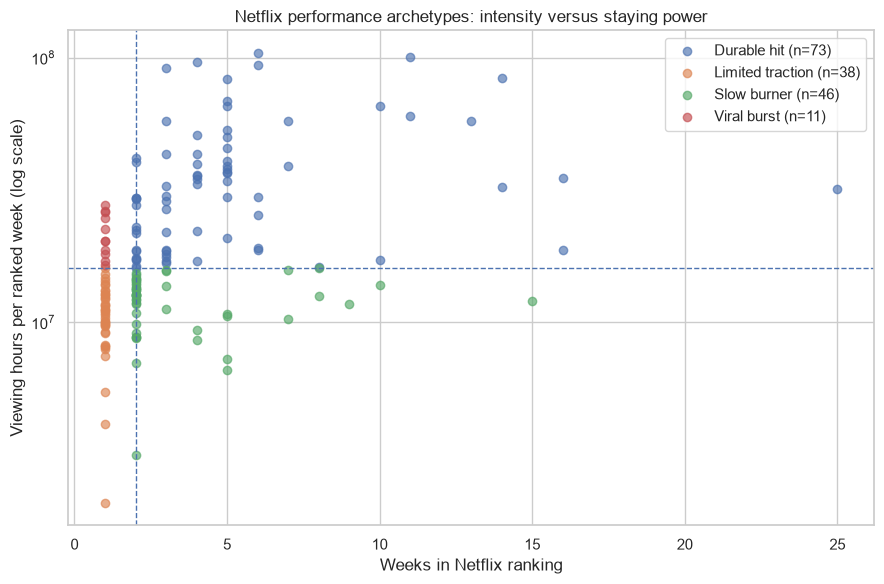

,Component,Recommendation,Evidence
0,Core genre,Action & Adventure,Balanced score = 0.76; n = 26; hit rate = 23.1%
1,Observed lifecycle,4+ seasons,Highest within-Action & Adventure lifecycle score = 0.92
2,Episode structure,≤8 episodes/season,Highest within-Action & Adventure format score = 0.75
3,Viewing commitment,Moderate (6–10 h),Highest within-Action & Adventure format score = 0.92
4,Language positioning,English,Highest within-Action & Adventure market score = 0.81
5,Performance objective,Durable hit: strong weekly demand plus sustained ranking,Durable-hit share in Action & Adventure: 57.7% versus 43.5% overall



### My Ideal Show Strategy

Rather than selecting the highest value from each dataset independently, I
looked for a format that balances four dimensions of success: **audience
quality**, **market reach**, **weekly viewing intensity**, and **staying
power**.

Among genres with at least **8 matched titles**,
**Action & Adventure** achieved the strongest overall balance. Its balanced score
was **0.76**, based on the percentile ranks
of confidence-adjusted IMDb rating, TMDb popularity, Netflix viewing hours per
ranked week, and weeks in the Netflix ranking. Its top-quartile viewing-hours
hit rate was **23.1%** across
**26 titles**.

Within Action & Adventure, the strongest observed lifecycle group was
**4+ seasons**. This should be interpreted as evidence of
multi-season durability rather than proof that producing more seasons causes
success, because popular shows are also more likely to receive renewals.

For controllable production choices, the data favors approximately
**≤8 episodes/season** and a **Moderate (6–10 h)** season. The strongest
language-market profile was **English** within the selected
genre. The target performance pattern is a **durable hit**: strong weekly
demand combined with sustained chart presence. In the selected genre,
**57.7%** of titles met this archetype,
compared with **43.5%** across the full
analysis sample.

These results describe associations rather than causal effects. The analysis
uses conservative exact-title matching, so it reduces false matches but also
excludes many titles. Production budget, marketing, release timing, platform
promotion, and target audience are not represented fully in the available
data.


In [59]:
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Optional: set True to save all report figures in ./exercise9_figures
EX9_SAVE_FIGURES = False
EX9_FIGURE_DIR = Path("exercise9_figures")
if EX9_SAVE_FIGURES:
    EX9_FIGURE_DIR.mkdir(exist_ok=True)


def ex9_finish_figure(filename: str) -> None:
    """Apply layout, optionally save, then show the current figure."""
    plt.tight_layout()
    if EX9_SAVE_FIGURES:
        plt.savefig(EX9_FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


# ============================================================
# 1. Helper functions
# ============================================================

def ex9_normalize_title(value):
    """Normalize a title for conservative exact matching."""
    if pd.isna(value):
        return np.nan

    text = unicodedata.normalize("NFKD", str(value))
    text = text.encode("ascii", "ignore").decode("ascii").lower()
    text = text.replace("&", " and ")
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def ex9_to_numeric(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Convert selected columns to numeric without modifying the input."""
    result = frame.copy()
    for column in columns:
        if column in result.columns:
            result[column] = pd.to_numeric(result[column], errors="coerce")
    return result


def ex9_binge_velocity(
    frame: pd.DataFrame,
    hours_col: str = "netflix_viewing_hours",
    weeks_col: str = "netflix_weeks",
) -> pd.Series:
    """Average viewing hours per week in the Netflix ranking."""
    weeks = frame[weeks_col].replace(0, np.nan)
    return (frame[hours_col] / weeks).rename("binge_velocity")


def ex9_bayesian_rating(
    frame: pd.DataFrame,
    rating_col: str,
    votes_col: str,
    prior_votes: int = 500,
) -> tuple[pd.Series, float]:
    """Shrink low-vote IMDb ratings toward the dataset-wide mean.

    WR = [v / (v + m)]R + [m / (v + m)]C

    R: title rating
    v: title vote count
    C: overall mean rating
    m: prior-vote confidence threshold
    """
    rating = pd.to_numeric(frame[rating_col], errors="coerce")
    votes = pd.to_numeric(frame[votes_col], errors="coerce").clip(lower=0)

    valid = rating.notna() & votes.notna()
    global_mean = rating[valid].mean()

    weighted = (
        (votes / (votes + prior_votes)) * rating
        + (prior_votes / (votes + prior_votes)) * global_mean
    )

    return weighted.rename("weighted_imdb_rating"), global_mean


def ex9_audience_alignment_gap(
    frame: pd.DataFrame,
    tmdb_col: str = "tmdb_vote_average",
    imdb_col: str = "imdb_averageRating",
) -> pd.Series:
    """Absolute disagreement between TMDb and IMDb ratings."""
    return (
        frame[tmdb_col] - frame[imdb_col]
    ).abs().rename("rating_alignment_gap")


def ex9_log_buzz(
    frame: pd.DataFrame,
    votes_col: str = "imdb_numVotes",
) -> pd.Series:
    """Log-transformed IMDb vote volume as an audience-attention feature."""
    votes = pd.to_numeric(frame[votes_col], errors="coerce").clip(lower=0)
    return np.log1p(votes).rename("imdb_buzz_log")


def ex9_label_hits(
    frame: pd.DataFrame,
    column: str = "netflix_viewing_hours",
    quantile: float = 0.75,
) -> tuple[pd.DataFrame, float]:
    """Label titles in the top performance quantile as hits."""
    result = frame.copy()
    threshold = result[column].quantile(quantile)
    result["is_hit"] = result[column] >= threshold
    return result, threshold


def ex9_rank_score(
    frame: pd.DataFrame,
    metric_columns: list[str],
    output_name: str,
) -> pd.DataFrame:
    """Convert metrics to percentile ranks and average them transparently."""
    result = frame.copy()
    percentile_columns = []

    for column in metric_columns:
        percentile_column = f"{column}_pct"
        result[percentile_column] = result[column].rank(
            pct=True,
            method="average",
        )
        percentile_columns.append(percentile_column)

    result[output_name] = result[percentile_columns].mean(axis=1)
    return result


# ============================================================
# 2. Validate inputs and construct a trusted cross-source sample
# ============================================================

required_netflix_columns = {
    "netflix_title",
    "netflix_viewing_hours",
    "netflix_weeks",
    "tmdb_title",
    "tmdb_popularity",
    "tmdb_vote_average",
    "tmdb_vote_count",
    "imdb_title",
    "imdb_averageRating",
    "imdb_numVotes",
}

required_tmdb_columns = {
    "id",
    "name",
    "original_name",
    "number_of_seasons",
    "number_of_episodes",
    "original_language",
    "vote_count",
    "vote_average",
    "popularity",
    "genres",
    "episode_run_time",
    "type",
    "status",
}

missing_netflix_columns = required_netflix_columns - set(netflix.columns)
missing_tmdb_columns = required_tmdb_columns - set(tmdb.columns)

if missing_netflix_columns:
    raise KeyError(
        f"Missing Netflix columns: {sorted(missing_netflix_columns)}"
    )

if missing_tmdb_columns:
    raise KeyError(
        f"Missing TMDb columns: {sorted(missing_tmdb_columns)}"
    )

# Work only on copies; original data remain unchanged.
ex9_base = netflix.copy().reset_index(drop=True)
ex9_base["ex9_row_id"] = np.arange(len(ex9_base))

ex9_base = ex9_to_numeric(
    ex9_base,
    [
        "netflix_viewing_hours",
        "netflix_weeks",
        "tmdb_popularity",
        "tmdb_vote_average",
        "tmdb_vote_count",
        "imdb_averageRating",
        "imdb_numVotes",
    ],
)

for title_column in ["netflix_title", "tmdb_title", "imdb_title"]:
    ex9_base[f"{title_column}_key"] = ex9_base[title_column].map(
        ex9_normalize_title
    )

# Conservative rule: keep only exact normalized title agreement.
# This sacrifices sample size to reduce false cross-source matches.
ex9_base["trusted_tmdb_title"] = (
    ex9_base["tmdb_title"].notna()
    & ex9_base["netflix_title_key"].eq(ex9_base["tmdb_title_key"])
)

ex9_base["trusted_imdb_title"] = (
    ex9_base["imdb_title"].notna()
    & ex9_base["netflix_title_key"].eq(ex9_base["imdb_title_key"])
)

# Create a TMDb lookup using both displayed and original titles.
ex9_tmdb_columns = [
    "id",
    "name",
    "original_name",
    "number_of_seasons",
    "number_of_episodes",
    "original_language",
    "vote_count",
    "vote_average",
    "popularity",
    "genres",
    "episode_run_time",
    "type",
    "status",
]

ex9_tmdb = ex9_to_numeric(
    tmdb[ex9_tmdb_columns].copy(),
    [
        "number_of_seasons",
        "number_of_episodes",
        "vote_count",
        "vote_average",
        "popularity",
        "episode_run_time",
    ],
)

ex9_tmdb["name_key"] = ex9_tmdb["name"].map(ex9_normalize_title)
ex9_tmdb["original_name_key"] = ex9_tmdb["original_name"].map(
    ex9_normalize_title
)

ex9_tmdb_lookup = pd.concat(
    [
        ex9_tmdb.assign(title_key=ex9_tmdb["name_key"]),
        ex9_tmdb.assign(title_key=ex9_tmdb["original_name_key"]),
    ],
    ignore_index=True,
)

ex9_tmdb_lookup = (
    ex9_tmdb_lookup[
        ex9_tmdb_lookup["title_key"].notna()
        & ex9_tmdb_lookup["title_key"].ne("")
    ]
    .drop_duplicates(["title_key", "id"])
)

ex9_trusted = ex9_base[
    ex9_base["trusted_tmdb_title"]
    & ex9_base["trusted_imdb_title"]
].copy()

# Duplicate titles may refer to multiple TMDb records.
# Choose the candidate whose TMDb metrics best reproduce the composite row.
ex9_candidates = ex9_trusted.merge(
    ex9_tmdb_lookup,
    left_on="tmdb_title_key",
    right_on="title_key",
    how="left",
    suffixes=("", "_tmdb_full"),
)

ex9_candidates["match_score"] = (
    (
        ex9_candidates["tmdb_vote_average"]
        - ex9_candidates["vote_average"]
    )
    .abs()
    .fillna(10)
    + (
        np.log1p(ex9_candidates["tmdb_vote_count"].clip(lower=0))
        - np.log1p(ex9_candidates["vote_count"].clip(lower=0))
    )
    .abs()
    .fillna(10)
    + (
        np.log1p(ex9_candidates["tmdb_popularity"].clip(lower=0))
        - np.log1p(ex9_candidates["popularity"].clip(lower=0))
    )
    .abs()
    .fillna(10)
)

ex9_analysis = (
    ex9_candidates
    .sort_values(
        ["ex9_row_id", "match_score", "vote_count"],
        ascending=[True, True, False],
    )
    .drop_duplicates("ex9_row_id")
    .copy()
)

# Focus on writer-relevant narrative television.
ex9_analysis = ex9_analysis[
    ex9_analysis["type"].isin(["Scripted", "Miniseries"])
].copy()

# Require usable outcome data.
ex9_analysis = ex9_analysis[
    ex9_analysis["netflix_viewing_hours"].gt(0)
    & ex9_analysis["netflix_weeks"].gt(0)
    & ex9_analysis["imdb_averageRating"].notna()
    & ex9_analysis["imdb_numVotes"].gt(0)
    & ex9_analysis["tmdb_popularity"].notna()
].copy()


# ============================================================
# 3. Create interpretable derived features
# ============================================================

# Weekly demand intensity
ex9_analysis["binge_velocity"] = ex9_binge_velocity(ex9_analysis)

# IMDb quality adjusted for vote confidence
(
    ex9_analysis["weighted_imdb_rating"],
    ex9_global_imdb_mean,
) = ex9_bayesian_rating(
    ex9_analysis,
    rating_col="imdb_averageRating",
    votes_col="imdb_numVotes",
    prior_votes=500,
)

# Cross-platform rating agreement and audience attention
ex9_analysis["rating_alignment_gap"] = ex9_audience_alignment_gap(
    ex9_analysis
)
ex9_analysis["imdb_buzz_log"] = ex9_log_buzz(ex9_analysis)

# Production-format features
ex9_analysis["episodes_per_season"] = (
    ex9_analysis["number_of_episodes"]
    / ex9_analysis["number_of_seasons"].replace(0, np.nan)
)

ex9_analysis["hours_per_season"] = (
    ex9_analysis["episodes_per_season"]
    * ex9_analysis["episode_run_time"].replace(0, np.nan)
    / 60
)

# Top-quartile total viewing-hours label
ex9_analysis, ex9_hit_threshold = ex9_label_hits(
    ex9_analysis,
    column="netflix_viewing_hours",
    quantile=0.75,
)

# Performance archetypes: weekly intensity × staying power
ex9_intensity_median = ex9_analysis["binge_velocity"].median()
ex9_staying_median = ex9_analysis["netflix_weeks"].median()

ex9_archetype_conditions = [
    (
        ex9_analysis["binge_velocity"].ge(ex9_intensity_median)
        & ex9_analysis["netflix_weeks"].ge(ex9_staying_median)
    ),
    (
        ex9_analysis["binge_velocity"].ge(ex9_intensity_median)
        & ex9_analysis["netflix_weeks"].lt(ex9_staying_median)
    ),
    (
        ex9_analysis["binge_velocity"].lt(ex9_intensity_median)
        & ex9_analysis["netflix_weeks"].ge(ex9_staying_median)
    ),
]

ex9_analysis["performance_archetype"] = np.select(
    ex9_archetype_conditions,
    ["Durable hit", "Viral burst", "Slow burner"],
    default="Limited traction",
)


# ============================================================
# 4. Evidence that robust summaries are appropriate
# ============================================================

ex9_distribution_summary = pd.DataFrame(
    {
        "Variable": [
            "TMDb popularity",
            "Netflix viewing hours",
            "Binge velocity",
            "IMDb vote count",
        ],
        "Count": [
            ex9_analysis["tmdb_popularity"].count(),
            ex9_analysis["netflix_viewing_hours"].count(),
            ex9_analysis["binge_velocity"].count(),
            ex9_analysis["imdb_numVotes"].count(),
        ],
        "Mean": [
            ex9_analysis["tmdb_popularity"].mean(),
            ex9_analysis["netflix_viewing_hours"].mean(),
            ex9_analysis["binge_velocity"].mean(),
            ex9_analysis["imdb_numVotes"].mean(),
        ],
        "Median": [
            ex9_analysis["tmdb_popularity"].median(),
            ex9_analysis["netflix_viewing_hours"].median(),
            ex9_analysis["binge_velocity"].median(),
            ex9_analysis["imdb_numVotes"].median(),
        ],
        "Skewness": [
            ex9_analysis["tmdb_popularity"].skew(),
            ex9_analysis["netflix_viewing_hours"].skew(),
            ex9_analysis["binge_velocity"].skew(),
            ex9_analysis["imdb_numVotes"].skew(),
        ],
        "95th percentile": [
            ex9_analysis["tmdb_popularity"].quantile(0.95),
            ex9_analysis["netflix_viewing_hours"].quantile(0.95),
            ex9_analysis["binge_velocity"].quantile(0.95),
            ex9_analysis["imdb_numVotes"].quantile(0.95),
        ],
    }
)

print("Distribution diagnostics")
display(ex9_distribution_summary.round(2))


# ============================================================
# 5. Show matching coverage before interpreting results
# ============================================================

ex9_coverage = pd.DataFrame(
    {
        "Stage": [
            "Netflix composite rows",
            "Exact IMDb title match",
            "Exact TMDb title match",
            "Exact match to both",
            "Narrative titles used",
        ],
        "Titles": [
            len(ex9_base),
            int(ex9_base["trusted_imdb_title"].sum()),
            int(ex9_base["trusted_tmdb_title"].sum()),
            int(
                (
                    ex9_base["trusted_imdb_title"]
                    & ex9_base["trusted_tmdb_title"]
                ).sum()
            ),
            len(ex9_analysis),
        ],
    }
)

ex9_coverage["Coverage (%)"] = (
    100 * ex9_coverage["Titles"] / len(ex9_base)
)

display(ex9_coverage.round(1))

plt.figure(figsize=(9, 4.8))
ex9_coverage_plot = ex9_coverage.iloc[1:].sort_values("Titles")
plt.barh(
    ex9_coverage_plot["Stage"],
    ex9_coverage_plot["Titles"],
)

for index, value in enumerate(ex9_coverage_plot["Titles"]):
    plt.text(value + 3, index, f"{int(value)}", va="center")

plt.xlabel("Number of titles")
plt.title("Cross-source matching and final analysis sample")
ex9_finish_figure("01_matching_coverage.png")


# ============================================================
# 6. Find the genre with the strongest overall balance
# ============================================================

ex9_genre_long = ex9_analysis.copy()
ex9_genre_long["genre"] = (
    ex9_genre_long["genres"]
    .fillna("")
    .str.split(r"\s*,\s*")
)
ex9_genre_long = ex9_genre_long.explode("genre")
ex9_genre_long["genre"] = ex9_genre_long["genre"].str.strip()
ex9_genre_long = ex9_genre_long[
    ex9_genre_long["genre"].ne("")
]

ex9_genre_profile = (
    ex9_genre_long
    .groupby("genre")
    .agg(
        title_count=("ex9_row_id", "nunique"),
        median_quality=("weighted_imdb_rating", "median"),
        median_reach=("tmdb_popularity", "median"),
        median_intensity=("binge_velocity", "median"),
        median_staying=("netflix_weeks", "median"),
        hit_rate=("is_hit", "mean"),
        median_alignment_gap=("rating_alignment_gap", "median"),
        median_buzz=("imdb_buzz_log", "median"),
    )
    .reset_index()
)

# Require a reasonable sample before ranking a genre.
ex9_min_genre_count = max(
    8,
    min(15, int(len(ex9_analysis) * 0.05)),
)

ex9_genre_profile = ex9_genre_profile[
    ex9_genre_profile["title_count"] >= ex9_min_genre_count
].copy()

# Equal-weight score across four distinct success dimensions.
ex9_genre_profile = ex9_rank_score(
    ex9_genre_profile,
    metric_columns=[
        "median_quality",
        "median_reach",
        "median_intensity",
        "median_staying",
    ],
    output_name="balanced_score",
)

ex9_genre_profile = (
    ex9_genre_profile
    .sort_values(
        ["balanced_score", "title_count"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

if ex9_genre_profile.empty:
    raise ValueError(
        "No genre has enough matched titles for a reliable comparison."
    )

best_genre = ex9_genre_profile.loc[0, "genre"]
best_genre_row = ex9_genre_profile.iloc[0]

print(
    f"Genres require at least {ex9_min_genre_count} matched titles."
)
display(
    ex9_genre_profile[
        [
            "genre",
            "title_count",
            "median_quality",
            "median_reach",
            "median_intensity",
            "median_staying",
            "hit_rate",
            "balanced_score",
        ]
    ]
    .head(10)
    .round(
        {
            "median_quality": 2,
            "median_reach": 2,
            "median_intensity": 0,
            "median_staying": 1,
            "hit_rate": 3,
            "balanced_score": 3,
        }
    )
)

# Figure: ranked balanced score
plt.figure(figsize=(9, 5.5))
ex9_top_genres = (
    ex9_genre_profile
    .head(10)
    .sort_values("balanced_score")
)

plt.barh(
    ex9_top_genres["genre"],
    ex9_top_genres["balanced_score"],
)
plt.xlabel("Balanced score (average percentile rank)")
plt.title(
    "Genres balancing quality, reach, intensity, and staying power"
)
plt.xlim(0, 1)
ex9_finish_figure("02_genre_balanced_score.png")

# Figure: quality-versus-reach positioning
plt.figure(figsize=(9, 6))
ex9_point_sizes = (
    60
    + 280
    * (
        ex9_genre_profile["median_staying"]
        / ex9_genre_profile["median_staying"].max()
    )
)

plt.scatter(
    ex9_genre_profile["median_reach"],
    ex9_genre_profile["median_quality"],
    s=ex9_point_sizes,
    alpha=0.7,
)

for _, row in ex9_genre_profile.head(8).iterrows():
    plt.annotate(
        row["genre"],
        (row["median_reach"], row["median_quality"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=9,
    )

plt.xscale("log")
plt.xlabel("Median TMDb popularity (log scale)")
plt.ylabel("Median confidence-adjusted IMDb rating")
plt.title("Genre positioning: audience quality versus market reach")
ex9_finish_figure("03_genre_quality_reach.png")


# ============================================================
# 7. Within the selected genre, identify a coherent format
# ============================================================

ex9_best_genre_titles = (
    ex9_genre_long[
        ex9_genre_long["genre"].eq(best_genre)
    ]
    .drop_duplicates("ex9_row_id")
    .copy()
)

# Number of seasons is partly an outcome of success, so it is reported as
# an observed lifecycle pattern rather than a guaranteed production choice.
ex9_best_genre_titles["season_plan"] = pd.cut(
    ex9_best_genre_titles["number_of_seasons"],
    bins=[0, 1, 3, np.inf],
    labels=["1 season", "2–3 seasons", "4+ seasons"],
)

ex9_best_genre_titles["episode_plan"] = pd.cut(
    ex9_best_genre_titles["episodes_per_season"],
    bins=[0, 8, 12, np.inf],
    labels=[
        "≤8 episodes/season",
        "9–12 episodes/season",
        "13+ episodes/season",
    ],
)

ex9_best_genre_titles["commitment_group"] = pd.cut(
    ex9_best_genre_titles["hours_per_season"],
    bins=[0, 6, 10, 16, np.inf],
    labels=[
        "Compact (≤6 h)",
        "Moderate (6–10 h)",
        "Extended (10–16 h)",
        "Long-form (>16 h)",
    ],
)

ex9_best_genre_titles["language_market"] = np.where(
    ex9_best_genre_titles["original_language"].eq("en"),
    "English",
    "Non-English",
)


def ex9_group_profile(
    frame: pd.DataFrame,
    group_column: str,
    minimum_count: int,
) -> pd.DataFrame:
    """Summarize and rank format groups within the chosen genre."""
    profile = (
        frame
        .dropna(subset=[group_column])
        .groupby(group_column, observed=True)
        .agg(
            title_count=("ex9_row_id", "nunique"),
            median_quality=("weighted_imdb_rating", "median"),
            median_reach=("tmdb_popularity", "median"),
            median_intensity=("binge_velocity", "median"),
            median_staying=("netflix_weeks", "median"),
            hit_rate=("is_hit", "mean"),
        )
        .reset_index()
    )

    reliable = profile[
        profile["title_count"] >= minimum_count
    ].copy()

    if reliable.empty:
        reliable = profile.copy()

    if reliable.empty:
        return reliable

    reliable = ex9_rank_score(
        reliable,
        metric_columns=[
            "median_quality",
            "median_reach",
            "median_intensity",
            "median_staying",
        ],
        output_name="format_score",
    )

    return (
        reliable
        .sort_values(
            ["format_score", "title_count"],
            ascending=[False, False],
        )
        .reset_index(drop=True)
    )


ex9_min_format_count = max(
    3,
    min(5, int(len(ex9_best_genre_titles) * 0.15)),
)

ex9_season_profile = ex9_group_profile(
    ex9_best_genre_titles,
    "season_plan",
    ex9_min_format_count,
)

ex9_episode_profile = ex9_group_profile(
    ex9_best_genre_titles,
    "episode_plan",
    ex9_min_format_count,
)

ex9_commitment_profile = ex9_group_profile(
    ex9_best_genre_titles,
    "commitment_group",
    ex9_min_format_count,
)

ex9_language_profile = ex9_group_profile(
    ex9_best_genre_titles,
    "language_market",
    ex9_min_format_count,
)

print(f"Conditional analysis within: {best_genre}")
print("Observed lifecycle profile")
display(ex9_season_profile.round(3))
print("Episodes per season")
display(ex9_episode_profile.round(3))
print("Viewing commitment per season")
display(ex9_commitment_profile.round(3))
print("Language market")
display(ex9_language_profile.round(3))

best_season_profile = (
    str(ex9_season_profile.loc[0, "season_plan"])
    if not ex9_season_profile.empty
    else "insufficient data"
)

best_episode_plan = (
    str(ex9_episode_profile.loc[0, "episode_plan"])
    if not ex9_episode_profile.empty
    else "insufficient data"
)

best_commitment_group = (
    str(ex9_commitment_profile.loc[0, "commitment_group"])
    if not ex9_commitment_profile.empty
    else "insufficient runtime data"
)

best_language_market = (
    str(ex9_language_profile.loc[0, "language_market"])
    if not ex9_language_profile.empty
    else "insufficient data"
)

# Figure: season viewing commitment within the selected genre
if not ex9_commitment_profile.empty:
    plt.figure(figsize=(9, 4.8))
    ex9_commitment_plot = ex9_commitment_profile.sort_values(
        "format_score"
    )

    plt.barh(
        ex9_commitment_plot["commitment_group"].astype(str),
        ex9_commitment_plot["format_score"],
    )
    plt.xlabel("Within-genre format score")
    plt.title(f"Season viewing commitment within {best_genre}")
    plt.xlim(0, 1)
    ex9_finish_figure("04_within_genre_commitment.png")


# ============================================================
# 8. Visualize Netflix performance archetypes
# ============================================================

plt.figure(figsize=(9, 6))

for archetype, group in ex9_analysis.groupby("performance_archetype"):
    plt.scatter(
        group["netflix_weeks"],
        group["binge_velocity"],
        alpha=0.65,
        label=f"{archetype} (n={len(group)})",
    )

plt.axvline(
    ex9_staying_median,
    linestyle="--",
    linewidth=1,
)
plt.axhline(
    ex9_intensity_median,
    linestyle="--",
    linewidth=1,
)
plt.yscale("log")
plt.xlabel("Weeks in Netflix ranking")
plt.ylabel("Viewing hours per ranked week (log scale)")
plt.title(
    "Netflix performance archetypes: intensity versus staying power"
)
plt.legend()
ex9_finish_figure("05_netflix_performance_archetypes.png")


# ============================================================
# 9. Produce the final recipe and automatic report paragraph
# ============================================================

ex9_best_genre_durable_share = (
    ex9_best_genre_titles["performance_archetype"]
    .eq("Durable hit")
    .mean()
)

ex9_overall_durable_share = (
    ex9_analysis["performance_archetype"]
    .eq("Durable hit")
    .mean()
)

ex9_recipe = pd.DataFrame(
    {
        "Component": [
            "Core genre",
            "Observed lifecycle",
            "Episode structure",
            "Viewing commitment",
            "Language positioning",
            "Performance objective",
        ],
        "Recommendation": [
            best_genre,
            best_season_profile,
            best_episode_plan,
            best_commitment_group,
            best_language_market,
            "Durable hit: strong weekly demand plus sustained ranking",
        ],
        "Evidence": [
            (
                f"Balanced score = {best_genre_row['balanced_score']:.2f}; "
                f"n = {int(best_genre_row['title_count'])}; "
                f"hit rate = {100 * best_genre_row['hit_rate']:.1f}%"
            ),
            (
                f"Highest within-{best_genre} lifecycle score = "
                f"{ex9_season_profile.loc[0, 'format_score']:.2f}"
                if not ex9_season_profile.empty
                else "Insufficient data"
            ),
            (
                f"Highest within-{best_genre} format score = "
                f"{ex9_episode_profile.loc[0, 'format_score']:.2f}"
                if not ex9_episode_profile.empty
                else "Insufficient data"
            ),
            (
                f"Highest within-{best_genre} format score = "
                f"{ex9_commitment_profile.loc[0, 'format_score']:.2f}"
                if not ex9_commitment_profile.empty
                else "Insufficient runtime data"
            ),
            (
                f"Highest within-{best_genre} market score = "
                f"{ex9_language_profile.loc[0, 'format_score']:.2f}"
                if not ex9_language_profile.empty
                else "Insufficient data"
            ),
            (
                f"Durable-hit share in {best_genre}: "
                f"{100 * ex9_best_genre_durable_share:.1f}% "
                f"versus {100 * ex9_overall_durable_share:.1f}% overall"
            ),
        ],
    }
)

display(ex9_recipe)

# Auto-generated written response for the exercise.
display(
    Markdown(
        f"""
### My Ideal Show Strategy

Rather than selecting the highest value from each dataset independently, I
looked for a format that balances four dimensions of success: **audience
quality**, **market reach**, **weekly viewing intensity**, and **staying
power**.

Among genres with at least **{ex9_min_genre_count} matched titles**,
**{best_genre}** achieved the strongest overall balance. Its balanced score
was **{best_genre_row['balanced_score']:.2f}**, based on the percentile ranks
of confidence-adjusted IMDb rating, TMDb popularity, Netflix viewing hours per
ranked week, and weeks in the Netflix ranking. Its top-quartile viewing-hours
hit rate was **{100 * best_genre_row['hit_rate']:.1f}%** across
**{int(best_genre_row['title_count'])} titles**.

Within {best_genre}, the strongest observed lifecycle group was
**{best_season_profile}**. This should be interpreted as evidence of
multi-season durability rather than proof that producing more seasons causes
success, because popular shows are also more likely to receive renewals.

For controllable production choices, the data favors approximately
**{best_episode_plan}** and a **{best_commitment_group}** season. The strongest
language-market profile was **{best_language_market}** within the selected
genre. The target performance pattern is a **durable hit**: strong weekly
demand combined with sustained chart presence. In the selected genre,
**{100 * ex9_best_genre_durable_share:.1f}%** of titles met this archetype,
compared with **{100 * ex9_overall_durable_share:.1f}%** across the full
analysis sample.

These results describe associations rather than causal effects. The analysis
uses conservative exact-title matching, so it reduces false matches but also
excludes many titles. Production budget, marketing, release timing, platform
promotion, and target audience are not represented fully in the available
data.
"""
    )
)

## our analysis
？？

In [60]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ==============================================================================
# 6. 在已篩選完成的 Hit 作品中建立排名分數
# ==============================================================================

# 確認 df_hits 已經存在
if "df_hits" not in globals():
    raise NameError("找不到 df_hits，請先執行 Hit 篩選程式。")

df_hit_rank = df_hits.copy()

# ------------------------------------------------------------------------------
# A. 整理排名使用的特徵
# ------------------------------------------------------------------------------

ranking_features = [
    "netflix_viewing_hours",
    "tmdb_vote_average",
    "tmdb_vote_count",
]

# 檢查必要欄位是否存在
missing_columns = [
    column
    for column in ranking_features + ["netflix_title"]
    if column not in df_hit_rank.columns
]

if missing_columns:
    raise KeyError(
        f"df_hits 缺少以下必要欄位：{missing_columns}"
    )

# 轉成數值，無法轉換的內容改成 NaN
for column in ranking_features:
    df_hit_rank[column] = pd.to_numeric(
        df_hit_rank[column],
        errors="coerce"
    )

# 排除三項排名特徵中有缺失值的作品
df_hit_rank = df_hit_rank.dropna(
    subset=ranking_features
).copy()

# 排除不合理數值
df_hit_rank = df_hit_rank[
    (df_hit_rank["netflix_viewing_hours"] >= 0) &
    (df_hit_rank["tmdb_vote_average"].between(0, 10)) &
    (df_hit_rank["tmdb_vote_count"] >= 0)
].copy()

if len(df_hit_rank) < 2:
    raise ValueError(
        "有效 Hit 作品少於 2 部，無法進行 PCA 排名。"
    )

# ------------------------------------------------------------------------------
# B. 對高度右偏的變數做 log 轉換
# ------------------------------------------------------------------------------

# 使用 log1p，即 log(1 + x)，降低極端值影響
df_hit_rank["log_viewing_hours"] = np.log1p(
    df_hit_rank["netflix_viewing_hours"]
)

df_hit_rank["log_tmdb_vote_count"] = np.log1p(
    df_hit_rank["tmdb_vote_count"]
)

# PCA 實際使用的三項特徵
pca_features = [
    "log_viewing_hours",
    "tmdb_vote_average",
    "log_tmdb_vote_count",
]

feature_names = [
    "Netflix viewing hours",
    "TMDb rating",
    "TMDb vote count",
]

# ------------------------------------------------------------------------------
# C. 選用：檢查 PCA 輸入特徵的 Pearson correlation
# ------------------------------------------------------------------------------

correlation_matrix = (
    df_hit_rank[pca_features]
    .corr(method="pearson")
)

correlation_matrix.index = feature_names
correlation_matrix.columns = feature_names

print("=" * 90)
print("Pearson correlation matrix of PCA input features")
print("=" * 90)
display(correlation_matrix.round(3))

# ------------------------------------------------------------------------------
# D. 檢查特徵是否具有變異
# ------------------------------------------------------------------------------

zero_variance_features = [
    feature
    for feature in pca_features
    if np.isclose(df_hit_rank[feature].std(ddof=0), 0)
]

if zero_variance_features:
    raise ValueError(
        "以下特徵在 Hit 資料中沒有變異，無法用於 PCA："
        f"{zero_variance_features}"
    )

# ------------------------------------------------------------------------------
# E. 標準化
# ------------------------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    df_hit_rank[pca_features]
)

# ------------------------------------------------------------------------------
# F. 執行 PCA
# ------------------------------------------------------------------------------

pca = PCA()

principal_components = pca.fit_transform(
    X_scaled
)

# 第一主成分作為共同 Hit 強度
pc1_scores = principal_components[:, 0].copy()

# PCA 正負方向沒有固定意義。
# 讓較高的原始指標大致對應較高的 PC1 分數。
if pca.components_[0].sum() < 0:
    pc1_scores *= -1
    pca.components_[0] *= -1

df_hit_rank["PCA_Hit_original"] = pc1_scores

# ------------------------------------------------------------------------------
# G. 將 PCA 分數轉成 0–100
# ------------------------------------------------------------------------------

score_min = df_hit_rank["PCA_Hit_original"].min()
score_max = df_hit_rank["PCA_Hit_original"].max()

if np.isclose(score_min, score_max):
    df_hit_rank["Hit_score"] = 50.0
else:
    df_hit_rank["Hit_score"] = (
        (
            df_hit_rank["PCA_Hit_original"]
            - score_min
        )
        /
        (
            score_max
            - score_min
        )
        * 100
    )

# ------------------------------------------------------------------------------
# H. 依 Hit 綜合分數排序
# ------------------------------------------------------------------------------

df_hit_rank = (
    df_hit_rank
    .sort_values(
        by=[
            "Hit_score",
            "netflix_viewing_hours"
        ],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

# 避免重複執行時欄位已經存在
if "Hit_rank" in df_hit_rank.columns:
    df_hit_rank = df_hit_rank.drop(
        columns=["Hit_rank"]
    )

df_hit_rank.insert(
    0,
    "Hit_rank",
    range(1, len(df_hit_rank) + 1)
)

# 建立百萬小時欄位
df_hit_rank["Viewing_hours_million"] = (
    df_hit_rank["netflix_viewing_hours"]
    / 1_000_000
).round(2)

# ------------------------------------------------------------------------------
# I. 顯示 PCA loading
# ------------------------------------------------------------------------------

loading_table = pd.DataFrame({
    "Feature": feature_names,
    "PC1_loading": pca.components_[0]
})

# 較標準的 PCA 相對貢獻：平方 loading
loading_table["Squared_loading"] = (
    loading_table["PC1_loading"] ** 2
)

loading_table["Relative_contribution_percent"] = (
    loading_table["Squared_loading"]
    /
    loading_table["Squared_loading"].sum()
    * 100
)

loading_table = (
    loading_table
    .sort_values(
        by="Relative_contribution_percent",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 90)
print("PC1 loadings and relative contributions")
print("=" * 90)

display(loading_table.round(4))

print(
    f"\nPC1 explained variance ratio: "
    f"{pca.explained_variance_ratio_[0] * 100:.2f}%"
)

# 同時顯示所有主成分的解釋變異比例
explained_variance_table = pd.DataFrame({
    "Principal_component": [
        f"PC{i + 1}"
        for i in range(len(pca.explained_variance_ratio_))
    ],
    "Explained_variance_percent": (
        pca.explained_variance_ratio_ * 100
    )
})

print("\nExplained variance by principal component:")
display(explained_variance_table.round(2))

# ------------------------------------------------------------------------------
# J. 最終 Hit 排名表
# ------------------------------------------------------------------------------

final_hit_ranking = df_hit_rank[[
    "Hit_rank",
    "netflix_title",
    "Hit_score",
    "Viewing_hours_million",
    "tmdb_vote_average",
    "tmdb_vote_count"
]].copy()

final_hit_ranking = final_hit_ranking.rename(columns={
    "Hit_rank": "Hit Rank",
    "netflix_title": "Title",
    "Hit_score": "Hit Composite Score",
    "Viewing_hours_million": "Viewing Hours (Million)",
    "tmdb_vote_average": "TMDb Rating",
    "tmdb_vote_count": "TMDb Vote Count"
})

final_hit_ranking["Hit Composite Score"] = (
    final_hit_ranking["Hit Composite Score"]
    .round(2)
)

final_hit_ranking["TMDb Rating"] = (
    final_hit_ranking["TMDb Rating"]
    .round(3)
)

print("\n" + "=" * 100)
print(
    f"Final PCA ranking of "
    f"{len(final_hit_ranking)} Hit titles"
)
print("=" * 100)

display(final_hit_ranking)

Pearson correlation matrix of PCA input features


,Netflix viewing hours,TMDb rating,TMDb vote count
Netflix viewing hours,1.000,0.169,0.522
TMDb rating,0.169,1.000,0.440
TMDb vote count,0.522,0.440,1.000



PC1 loadings and relative contributions


,Feature,PC1_loading,Squared_loading,Relative_contribution_percent
0,TMDb vote count,0.6626,0.4390,43.9014
1,Netflix viewing hours,0.5578,0.3111,31.1142
2,TMDb rating,0.4998,0.2498,24.9844



PC1 explained variance ratio: 59.03%

Explained variance by principal component:


,Principal_component,Explained_variance_percent
0,PC1,59.03
1,PC2,27.81
2,PC3,13.17



Final PCA ranking of 71 Hit titles


,Hit Rank,Title,Hit Composite Score,Viewing Hours (Million),TMDb Rating,TMDb Vote Count
0,1,Stranger Things,100.00,2874.26,8.624,16161.0
1,2,Money Heist,84.49,1170.20,8.257,17836.0
2,3,Squid Game,82.90,2289.50,7.831,13053.0
3,4,The Umbrella Academy,74.10,414.63,8.604,8891.0
4,5,Sex Education,70.62,561.36,8.304,6647.0
5,6,All of Us Are Dead,68.76,659.51,8.354,3335.0
6,7,Bridgerton,67.90,1108.80,8.143,2045.0
7,8,Ozark,64.97,751.60,8.244,1968.0
8,9,Peaky Blinders,64.08,185.34,8.546,8836.0
9,10,Cobra Kai,64.00,383.64,8.220,5734.0


## our analysis
？？

In [61]:
# ==============================================================================
# J. PCA ranking + all Netflix features + all TMDb features
# Compatible with:
# Hit_rank, Hit_score, PCA_Hit_original,
# log_viewing_hours, log_tmdb_vote_count, Viewing_hours_million
# ==============================================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------------------------

# df:
# Netflix composite dataset
#
# tmdb:
# TMDb v3 dataset
#
# df_hit_rank:
# PCA-ranked Hit dataset

netflix_all = df.copy()
tmdb_all = tmdb.copy()

required_objects = {
    "df_hit_rank": df_hit_rank,
    "netflix_all": netflix_all,
    "tmdb_all": tmdb_all
}

for object_name, dataframe in required_objects.items():
    if not isinstance(dataframe, pd.DataFrame):
        raise TypeError(
            f"{object_name} is not a valid DataFrame."
        )

# Check required ID column
if "key" not in df_hit_rank.columns:
    raise KeyError(
        "The 'key' column is missing from df_hit_rank."
    )

if "key" not in netflix_all.columns:
    raise KeyError(
        "The 'key' column is missing from the Netflix composite dataset."
    )


# ------------------------------------------------------------------------------
# 2. Preserve PCA-derived columns
# ------------------------------------------------------------------------------

# Columns created during PCA but not present in the original Netflix CSV
pca_derived_columns = [
    column
    for column in df_hit_rank.columns
    if column not in netflix_all.columns
    and column != "key"
]

rank_information = df_hit_rank[
    ["key"] + pca_derived_columns
].copy()


# ------------------------------------------------------------------------------
# 3. Merge all original Netflix composite features
# ------------------------------------------------------------------------------

df_ranked_all_features = rank_information.merge(
    netflix_all,
    on="key",
    how="left",
    validate="one_to_one"
)

print(
    f"Netflix composite merge completed: "
    f"{len(df_ranked_all_features)} Hit titles, "
    f"{len(netflix_all.columns)} original Netflix columns."
)


# ------------------------------------------------------------------------------
# 4. Construct reliable TMDb matching keys
# ------------------------------------------------------------------------------

def normalize_title(series):
    """
    Normalize titles by removing extra spaces
    and ignoring capitalization differences.
    """
    return (
        series
        .astype("string")
        .str.strip()
        .str.casefold()
        .str.replace(r"\s+", " ", regex=True)
    )


# Netflix composite side
df_ranked_all_features["_match_title"] = normalize_title(
    df_ranked_all_features["tmdb_title"]
)

df_ranked_all_features["_match_popularity"] = pd.to_numeric(
    df_ranked_all_features["tmdb_popularity"],
    errors="coerce"
).round(6)

df_ranked_all_features["_match_rating"] = pd.to_numeric(
    df_ranked_all_features["tmdb_vote_average"],
    errors="coerce"
).round(6)

df_ranked_all_features["_match_votes"] = pd.to_numeric(
    df_ranked_all_features["tmdb_vote_count"],
    errors="coerce"
).round().astype("Int64")


# Original TMDb side
tmdb_for_merge = tmdb_all.copy()

tmdb_for_merge["_match_title"] = normalize_title(
    tmdb_for_merge["name"]
)

tmdb_for_merge["_match_popularity"] = pd.to_numeric(
    tmdb_for_merge["popularity"],
    errors="coerce"
).round(6)

tmdb_for_merge["_match_rating"] = pd.to_numeric(
    tmdb_for_merge["vote_average"],
    errors="coerce"
).round(6)

tmdb_for_merge["_match_votes"] = pd.to_numeric(
    tmdb_for_merge["vote_count"],
    errors="coerce"
).round().astype("Int64")


match_columns = [
    "_match_title",
    "_match_popularity",
    "_match_rating",
    "_match_votes"
]


# ------------------------------------------------------------------------------
# 5. Keep only TMDb candidates required for the current Hit titles
# ------------------------------------------------------------------------------

needed_match_keys = (
    df_ranked_all_features[match_columns]
    .drop_duplicates()
    .copy()
)

tmdb_candidates = tmdb_for_merge.merge(
    needed_match_keys,
    on=match_columns,
    how="inner"
)

print(
    f"Current Hit titles: {len(df_ranked_all_features)}; "
    f"TMDb candidate records found: {len(tmdb_candidates)}."
)


# ------------------------------------------------------------------------------
# 6. Remove duplicate TMDb records
# ------------------------------------------------------------------------------

# If the same TMDb ID appears more than once, keep only the first record
if "id" in tmdb_candidates.columns:
    tmdb_candidates = tmdb_candidates.drop_duplicates(
        subset=["id"],
        keep="first"
    )

# Detect whether the same matching key still corresponds to multiple records
duplicate_match_mask = tmdb_candidates.duplicated(
    subset=match_columns,
    keep=False
)

if duplicate_match_mask.any():

    ambiguous_matches = (
        tmdb_candidates.loc[duplicate_match_mask]
        .sort_values(match_columns)
    )

    display_columns = [
        column
        for column in [
            "id",
            "name",
            "first_air_date",
            "last_air_date",
            "original_language",
            "popularity",
            "vote_average",
            "vote_count"
        ]
        if column in ambiguous_matches.columns
    ]

    print(
        "The following titles have multiple possible TMDb matches:"
    )

    display(
        ambiguous_matches[display_columns]
    )

    raise ValueError(
        "Some Hit titles cannot be uniquely matched to TMDb. "
        "Additional keys such as release year or TMDb ID are required."
    )


# ------------------------------------------------------------------------------
# 7. Confirm that every Hit title has exactly one TMDb match
# ------------------------------------------------------------------------------

match_check = (
    df_ranked_all_features[match_columns]
    .merge(
        tmdb_candidates[match_columns],
        on=match_columns,
        how="left",
        indicator=True
    )
)

unmatched_count = (
    match_check["_merge"] == "left_only"
).sum()

if unmatched_count > 0:

    unmatched_keys = match_check.loc[
        match_check["_merge"] == "left_only",
        match_columns
    ]

    print(
        f"{unmatched_count} Hit titles could not be matched to TMDb:"
    )

    display(unmatched_keys)

    raise ValueError(
        "Some Hit titles were not successfully matched "
        "to the original TMDb dataset."
    )

print(
    "All Hit titles were successfully matched "
    "to unique TMDb records."
)


# ------------------------------------------------------------------------------
# 8. Add a prefix to every original TMDb column
# ------------------------------------------------------------------------------

tmdb_original_columns = list(tmdb_all.columns)

tmdb_prefix_mapping = {
    column: f"TMDb_raw_{column}"
    for column in tmdb_original_columns
}

tmdb_candidates = tmdb_candidates.rename(
    columns=tmdb_prefix_mapping
)


# ------------------------------------------------------------------------------
# 9. Merge all original TMDb features
# ------------------------------------------------------------------------------

df_ranked_all_features = df_ranked_all_features.merge(
    tmdb_candidates,
    on=match_columns,
    how="left",
    validate="one_to_one"
)

print(
    f"TMDb merge completed: "
    f"{len(tmdb_original_columns)} original TMDb columns added."
)


# ------------------------------------------------------------------------------
# 10. Remove temporary matching columns
# ------------------------------------------------------------------------------

df_ranked_all_features = df_ranked_all_features.drop(
    columns=match_columns,
    errors="ignore"
)


# ------------------------------------------------------------------------------
# 11. Reorder columns
# ------------------------------------------------------------------------------

# Main PCA ranking columns
ranking_front_columns = [
    "Hit_rank",
    "Hit_score",
    "PCA_Hit_original"
]

ranking_front_columns = [
    column
    for column in ranking_front_columns
    if column in df_ranked_all_features.columns
]

# All original Netflix composite columns
netflix_original_columns = [
    column
    for column in netflix_all.columns
    if column in df_ranked_all_features.columns
]

# All original TMDb columns with prefix
tmdb_prefixed_columns = [
    f"TMDb_raw_{column}"
    for column in tmdb_original_columns
    if f"TMDb_raw_{column}"
    in df_ranked_all_features.columns
]

# Other PCA-derived columns
other_derived_columns = [
    column
    for column in pca_derived_columns
    if column not in ranking_front_columns
    and column in df_ranked_all_features.columns
]

ordered_columns = (
    ranking_front_columns
    + netflix_original_columns
    + tmdb_prefixed_columns
    + other_derived_columns
)

# Remove any duplicate column names while preserving order
ordered_columns = list(
    dict.fromkeys(ordered_columns)
)

remaining_columns = [
    column
    for column in df_ranked_all_features.columns
    if column not in ordered_columns
]

df_ranked_all_features = df_ranked_all_features[
    ordered_columns + remaining_columns
]


# ------------------------------------------------------------------------------
# 12. Preserve the PCA ranking order
# ------------------------------------------------------------------------------

df_ranked_all_features = (
    df_ranked_all_features
    .sort_values(
        by="Hit_rank",
        ascending=True
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------------------------
# 13. Optional: round important PCA result columns
# ------------------------------------------------------------------------------

columns_to_round = {
    "Hit_score": 2,
    "PCA_Hit_original": 4,
    "Viewing_hours_million": 2,
    "tmdb_vote_average": 3
}

for column, decimal_places in columns_to_round.items():
    if column in df_ranked_all_features.columns:
        df_ranked_all_features[column] = (
            pd.to_numeric(
                df_ranked_all_features[column],
                errors="coerce"
            ).round(decimal_places)
        )


# ------------------------------------------------------------------------------
# 14. Display all combined features
# ------------------------------------------------------------------------------

print("\n" + "=" * 130)
print(
    "PCA-ranked Hit titles with all Netflix and TMDb features"
)
print(
    f"Number of Hit titles: "
    f"{len(df_ranked_all_features)}"
)
print(
    f"Total number of columns: "
    f"{df_ranked_all_features.shape[1]}"
)
print(
    f"Original Netflix columns: "
    f"{len(netflix_original_columns)}"
)
print(
    f"Original TMDb columns: "
    f"{len(tmdb_prefixed_columns)}"
)
print(
    f"PCA-derived columns: "
    f"{len(pca_derived_columns)}"
)
print("=" * 130)

with pd.option_context(
    "display.max_columns", None,
    "display.max_rows", None,
    "display.max_colwidth", 150,
    "display.width", None
):
    display(df_ranked_all_features)


# ------------------------------------------------------------------------------
# 15. Export the complete result to CSV
# ------------------------------------------------------------------------------

output_path = (
    "netflix/data/"
    "PCA_Hit_ranking_3features_with_all_Netflix_TMDb_features.csv"
)

df_ranked_all_features.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print(
    f"\nComplete PCA ranking data exported to:\n"
    f"{output_path}"
)

Netflix composite merge completed: 71 Hit titles, 13 original Netflix columns.
Current Hit titles: 71; TMDb candidate records found: 71.
All Hit titles were successfully matched to unique TMDb records.
TMDb merge completed: 29 original TMDb columns added.

PCA-ranked Hit titles with all Netflix and TMDb features
Number of Hit titles: 71
Total number of columns: 53
Original Netflix columns: 13
Original TMDb columns: 29
PCA-derived columns: 11


,Hit_rank,Hit_score,PCA_Hit_original,key,netflix_viewing_hours,netflix_weeks,netflix_year_hint,netflix_title,netflix_clean_title,tmdb_title,tmdb_popularity,tmdb_vote_average,tmdb_vote_count,imdb_title,imdb_averageRating,imdb_numVotes,TMDb_raw_id,TMDb_raw_name,TMDb_raw_number_of_seasons,TMDb_raw_number_of_episodes,TMDb_raw_original_language,TMDb_raw_vote_count,TMDb_raw_vote_average,TMDb_raw_overview,TMDb_raw_adult,TMDb_raw_backdrop_path,TMDb_raw_first_air_date,TMDb_raw_last_air_date,TMDb_raw_homepage,TMDb_raw_in_production,TMDb_raw_original_name,TMDb_raw_popularity,TMDb_raw_poster_path,TMDb_raw_type,TMDb_raw_status,TMDb_raw_tagline,TMDb_raw_genres,TMDb_raw_created_by,TMDb_raw_languages,TMDb_raw_networks,TMDb_raw_origin_country,TMDb_raw_spoken_languages,TMDb_raw_production_companies,TMDb_raw_production_countries,TMDb_raw_episode_run_time,netflix_viewing_hours_norm,netflix_weeks_norm,tmdb_vote_average_norm,tmdb_vote_count_norm,綜合 The Hit 指數,log_viewing_hours,log_tmdb_vote_count,Viewing_hours_million
0,1,100.00,3.8578,st_th,2874260000,13,2022,Stranger Things,stranger things,Stranger Things,185.711,8.624,16161.0,Stranger Things,NaN,NaN,66732,Stranger Things,4,34,en,16161,8.624,"When a young boy vanishes, a small town uncovers a mystery involving secret experiments, terrifying supernatural forces, and one strange little girl.",False,/2MaumbgBlW1NoPo3ZJO38A6v7OS.jpg,2016-07-15,2022-07-01,https://www.netflix.com/title/80057281,True,Stranger Things,185.711,/49WJfeN0moxb9IPfGn8AIqMGskD.jpg,Scripted,Returning Series,Every ending has a beginning.,"Drama, Sci-Fi & Fantasy, Mystery","Matt Duffer, Ross Duffer",en,Netflix,US,English,"21 Laps Entertainment, Monkey Massacre Productions",United States of America,0,1.000000,0.478261,0.902222,0.905952,0.8522,21.779061,9.690418,2874.26
1,2,84.49,2.9029,he_mo,1170200000,14,2021,Money Heist,money heist,Money Heist,96.354,8.257,17836.0,Money Heist,8.2,612436.0,71446,Money Heist,3,41,es,17836,8.257,"To carry out the biggest heist in history, a mysterious man called The Professor recruits a band of eight robbers who have a single characteristic...",False,/gFZriCkpJYsApPZEF3jhxL4yLzG.jpg,2017-05-02,2021-12-03,https://www.netflix.com/title/80192098,False,La Casa de Papel,96.354,/reEMJA1uzscCbkpeRJeTT2bjqUp.jpg,Scripted,Ended,The perfect robbery.,"Crime, Drama",Álex Pina,es,"Netflix, Antena 3",ES,Español,Vancouver Media,Spain,70,0.392052,0.521739,0.698333,1.000000,0.6011,20.880441,9.789030,1170.20
2,3,82.90,2.8051,ga_sq,2289500000,20,2021,Squid Game,squid game,Squid Game,115.587,7.831,13053.0,Squid Game!,NaN,NaN,93405,Squid Game,2,9,ko,13053,7.831,"Hundreds of cash-strapped players accept a strange invitation to compete in children's games—with high stakes. But, a tempting prize awaits the vi...",False,/2meX1nMdScFOoV4370rqHWKmXhY.jpg,2021-09-17,2021-09-17,https://www.netflix.com/title/81040344,True,오징어 게임,115.587,/dDlEmu3EZ0Pgg93K2SVNLCjCSvE.jpg,Scripted,Returning Series,45.6 billion won is child's play,"Action & Adventure, Mystery, Drama",Hwang Dong-hyuk,"en, ko, ur",Netflix,KR,"English, 한국어/조선말, اردو","Siren Pictures, Firstman Studio",South Korea,0,0.791378,0.782609,0.461667,0.731443,0.6817,21.551599,9.476850,2289.50
3,4,74.10,2.2635,ac_um,414630000,5,2022,The Umbrella Academy,the umbrella academy,The Umbrella Academy,51.859,8.604,8891.0,The Umbrella Academy,7.0,74.0,75006,The Umbrella Academy,4,32,en,8891,8.604,"A dysfunctional family of superheroes comes together to solve the mystery of their father's death, the threat of the apocalypse and more.",False,/7sqFEDDmK1hG5m92upolcfQxy7R.jpg,2019-02-15,2022-06-22,https://www.netflix.com/title/80186863,True,The Umbrella Academy,51.859,/qhcwrnnCnN8NE1N6XXKHFmveJR9.jpg,Scripted,Returning Series,Too many siblings. Not enough timeline.,"Action & Adventure, Sci-Fi & Fantasy, Drama",Steve Blackman,en,Netflix,US,English,"Dark Horse Entertainment, UCP","Canada, United States of America",0,0.122492,0.130435,0.891111,0.497754,0.4110,19.842897,9.092907,414.63
4,5,70.62


Complete PCA ranking data exported to:
netflix/data/PCA_Hit_ranking_3features_with_all_Netflix_TMDb_features.csv


## our analysis
？？

In [62]:
# ==============================================================================
# K. Genre analysis for the 32 PCA-ranked Hit titles
# ==============================================================================

import ast
import json
import re
import pandas as pd
import numpy as np

# ------------------------------------------------------------------------------
# 1. Settings
# ------------------------------------------------------------------------------

TOP_N = 10

DATAFRAME_NAME = "df_ranked_all_features"
GENRE_COLUMN = "TMDb_raw_genres"
RANK_COLUMN = "Hit_rank"
SCORE_COLUMN = "Hit_score"

# Automatically select a usable title column
possible_title_columns = [
    "netflix_title",
    "TMDb_raw_name",
    "tmdb_title",
    "title",
    "name"
]

title_column = next(
    (
        column
        for column in possible_title_columns
        if column in df_ranked_all_features.columns
    ),
    None
)

if title_column is None:
    raise KeyError(
        "No usable title column was found. "
        f"Checked: {possible_title_columns}"
    )

required_columns = [
    GENRE_COLUMN,
    RANK_COLUMN,
    title_column
]

missing_columns = [
    column
    for column in required_columns
    if column not in df_ranked_all_features.columns
]

if missing_columns:
    raise KeyError(
        f"Missing required columns: {missing_columns}"
    )


# ------------------------------------------------------------------------------
# 2. Robust parser for TMDb_raw_genres
# ------------------------------------------------------------------------------

def parse_genres(value):
    """
    Convert different genre formats into a clean list of genre names.

    Supported examples:
    - ['Drama', 'Crime']
    - "['Drama', 'Crime']"
    - [{"id": 18, "name": "Drama"}]
    - '[{"id": 18, "name": "Drama"}]'
    - "Drama, Crime"
    - "Drama | Crime"
    """

    if value is None:
        return []

    if isinstance(value, float) and np.isnan(value):
        return []

    parsed_value = value

    # Try to parse string representations of Python/JSON objects
    if isinstance(value, str):
        text = value.strip()

        if not text or text.casefold() in {
            "nan", "none", "null", "[]", "{}"
        }:
            return []

        parsed_successfully = False

        # Try JSON
        try:
            parsed_value = json.loads(text)
            parsed_successfully = True
        except (json.JSONDecodeError, TypeError):
            pass

        # Try Python literal syntax
        if not parsed_successfully:
            try:
                parsed_value = ast.literal_eval(text)
                parsed_successfully = True
            except (ValueError, SyntaxError):
                pass

        # Fall back to comma, pipe, semicolon, or slash separation
        if not parsed_successfully:
            parsed_value = re.split(
                r"\s*[,|;/]\s*",
                text
            )

    # One dictionary, such as {"id": 18, "name": "Drama"}
    if isinstance(parsed_value, dict):
        parsed_value = [parsed_value]

    # Convert one scalar value to a list
    if not isinstance(parsed_value, (list, tuple, set)):
        parsed_value = [parsed_value]

    clean_genres = []

    for item in parsed_value:

        # TMDb dictionary format
        if isinstance(item, dict):
            genre_name = (
                item.get("name")
                or item.get("genre")
                or item.get("genre_name")
            )
        else:
            genre_name = item

        if genre_name is None:
            continue

        genre_name = str(genre_name).strip()

        # Remove unnecessary quotes and brackets
        genre_name = genre_name.strip(
            "[]{}()\"'"
        ).strip()

        if (
            genre_name
            and genre_name.casefold()
            not in {"nan", "none", "null"}
        ):
            clean_genres.append(genre_name)

    # Remove duplicates within the same title
    clean_genres = list(dict.fromkeys(clean_genres))

    return clean_genres


# ------------------------------------------------------------------------------
# 3. Prepare genre lists
# ------------------------------------------------------------------------------

genre_data = (
    df_ranked_all_features
    .sort_values(RANK_COLUMN)
    .copy()
)

genre_data["Genre_list"] = (
    genre_data[GENRE_COLUMN]
    .apply(parse_genres)
)

total_titles = len(genre_data)

if total_titles == 0:
    raise ValueError(
        "df_ranked_all_features contains no rows."
    )

titles_without_genres = (
    genre_data["Genre_list"]
    .map(len)
    .eq(0)
    .sum()
)

print("=" * 100)
print("Genre analysis of PCA-ranked Hit titles")
print("=" * 100)
print(f"Number of Hit titles: {total_titles}")
print(f"Titles without genre information: {titles_without_genres}")


# ------------------------------------------------------------------------------
# 4. Overall genre counts across all Hit titles
# ------------------------------------------------------------------------------

overall_genre_counts = (
    genre_data[["Genre_list"]]
    .explode("Genre_list")
    .dropna(subset=["Genre_list"])
    .groupby("Genre_list")
    .size()
    .reset_index(name="Title Count")
    .rename(columns={
        "Genre_list": "Genre"
    })
)

overall_genre_counts["Percentage of All Hits (%)"] = (
    overall_genre_counts["Title Count"]
    / total_titles
    * 100
)

overall_genre_counts = (
    overall_genre_counts
    .sort_values(
        by=[
            "Title Count",
            "Genre"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

overall_genre_counts.insert(
    0,
    "Genre Rank",
    range(1, len(overall_genre_counts) + 1)
)

overall_genre_counts[
    "Percentage of All Hits (%)"
] = overall_genre_counts[
    "Percentage of All Hits (%)"
].round(1)

print("\n" + "-" * 100)
print(f"Genre frequency among all {total_titles} Hit titles")
print("-" * 100)

display(overall_genre_counts)


# ------------------------------------------------------------------------------
# 5. Display genres for each of the top-N titles
# ------------------------------------------------------------------------------

actual_top_n = min(
    TOP_N,
    total_titles
)

top_n_data = (
    genre_data
    .head(actual_top_n)
    .copy()
)

top_n_data["Genres"] = (
    top_n_data["Genre_list"]
    .apply(
        lambda genre_list:
        ", ".join(genre_list)
        if genre_list
        else "Missing"
    )
)

top_title_columns = [
    RANK_COLUMN,
    title_column
]

if SCORE_COLUMN in top_n_data.columns:
    top_title_columns.append(SCORE_COLUMN)

top_title_columns.append("Genres")

top_titles_genre_table = (
    top_n_data[top_title_columns]
    .copy()
)

top_titles_genre_table = top_titles_genre_table.rename(columns={
    RANK_COLUMN: "Hit Rank",
    title_column: "Title",
    SCORE_COLUMN: "Hit Score"
})

if "Hit Score" in top_titles_genre_table.columns:
    top_titles_genre_table["Hit Score"] = (
        pd.to_numeric(
            top_titles_genre_table["Hit Score"],
            errors="coerce"
        ).round(2)
    )

print("\n" + "-" * 100)
print(f"Genres of the top {actual_top_n} Hit titles")
print("-" * 100)

display(top_titles_genre_table)


# ------------------------------------------------------------------------------
# 6. Genre counts among the top-N titles
# ------------------------------------------------------------------------------

top_n_genre_counts = (
    top_n_data[["Genre_list"]]
    .explode("Genre_list")
    .dropna(subset=["Genre_list"])
    .groupby("Genre_list")
    .size()
    .reset_index(name=f"Top {actual_top_n} Count")
    .rename(columns={
        "Genre_list": "Genre"
    })
)

top_n_genre_counts[
    f"Top {actual_top_n} Percentage (%)"
] = (
    top_n_genre_counts[
        f"Top {actual_top_n} Count"
    ]
    / actual_top_n
    * 100
)

top_n_genre_counts = (
    top_n_genre_counts
    .sort_values(
        by=[
            f"Top {actual_top_n} Count",
            "Genre"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

top_n_genre_counts[
    f"Top {actual_top_n} Percentage (%)"
] = top_n_genre_counts[
    f"Top {actual_top_n} Percentage (%)"
].round(1)

print("\n" + "-" * 100)
print(f"Genre frequency among the top {actual_top_n} titles")
print("-" * 100)

display(top_n_genre_counts)


# ------------------------------------------------------------------------------
# 7. Compare top-N genre prevalence with all Hit titles
# ------------------------------------------------------------------------------

genre_comparison = top_n_genre_counts.merge(
    overall_genre_counts[[
        "Genre",
        "Title Count",
        "Percentage of All Hits (%)"
    ]],
    on="Genre",
    how="outer"
)

genre_comparison[
    f"Top {actual_top_n} Count"
] = genre_comparison[
    f"Top {actual_top_n} Count"
].fillna(0).astype(int)

genre_comparison["Title Count"] = (
    genre_comparison["Title Count"]
    .fillna(0)
    .astype(int)
)

genre_comparison[
    f"Top {actual_top_n} Percentage (%)"
] = genre_comparison[
    f"Top {actual_top_n} Percentage (%)"
].fillna(0)

genre_comparison[
    "Percentage of All Hits (%)"
] = genre_comparison[
    "Percentage of All Hits (%)"
].fillna(0)

genre_comparison[
    "Top-vs-All Difference (percentage points)"
] = (
    genre_comparison[
        f"Top {actual_top_n} Percentage (%)"
    ]
    -
    genre_comparison[
        "Percentage of All Hits (%)"
    ]
).round(1)

genre_comparison = (
    genre_comparison
    .sort_values(
        by=[
            f"Top {actual_top_n} Count",
            "Top-vs-All Difference (percentage points)",
            "Title Count"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

print("\n" + "-" * 100)
print(
    f"Genre comparison: top {actual_top_n} "
    f"versus all {total_titles} Hit titles"
)
print("-" * 100)

display(genre_comparison)


# ------------------------------------------------------------------------------
# 8. Union and intersection of genres in the top-N titles
# ------------------------------------------------------------------------------

top_genre_sets = [
    set(genres)
    for genres in top_n_data["Genre_list"]
    if genres
]

if top_genre_sets:
    genres_appearing_in_top_n = sorted(
        set.union(*top_genre_sets)
    )

    genres_shared_by_all_top_n = sorted(
        set.intersection(*top_genre_sets)
    )
else:
    genres_appearing_in_top_n = []
    genres_shared_by_all_top_n = []

print("\n" + "-" * 100)
print(f"Genre coverage in the top {actual_top_n}")
print("-" * 100)

print(
    f"Genres appearing in at least one top-{actual_top_n} title:"
)
print(
    ", ".join(genres_appearing_in_top_n)
    if genres_appearing_in_top_n
    else "None"
)

print(
    f"\nGenres shared by every top-{actual_top_n} title:"
)
print(
    ", ".join(genres_shared_by_all_top_n)
    if genres_shared_by_all_top_n
    else "No single genre is shared by every top-ranked title."
)

Genre analysis of PCA-ranked Hit titles
Number of Hit titles: 71
Titles without genre information: 0

----------------------------------------------------------------------------------------------------
Genre frequency among all 71 Hit titles
----------------------------------------------------------------------------------------------------


,Genre Rank,Genre,Title Count,Percentage of All Hits (%)
0,1,Drama,62,87.3
1,2,Mystery,18,25.4
2,3,Crime,17,23.9
3,4,Sci-Fi & Fantasy,15,21.1
4,5,Comedy,13,18.3
5,6,Action & Adventure,12,16.9
6,7,Reality,3,4.2
7,8,War & Politics,3,4.2
8,9,Animation,2,2.8
9,10,Soap,2,2.8



----------------------------------------------------------------------------------------------------
Genres of the top 10 Hit titles
----------------------------------------------------------------------------------------------------


,Hit Rank,Title,Hit Score,Genres
0,1,Stranger Things,100.00,"Drama, Sci-Fi & Fantasy, Mystery"
1,2,Money Heist,84.49,"Crime, Drama"
2,3,Squid Game,82.90,"Action & Adventure, Mystery, Drama"
3,4,The Umbrella Academy,74.10,"Action & Adventure, Sci-Fi & Fantasy, Drama"
4,5,Sex Education,70.62,"Comedy, Drama"
5,6,All of Us Are Dead,68.76,"Action & Adventure, Drama, Sci-Fi & Fantasy"
6,7,Bridgerton,67.90,Drama
7,8,Ozark,64.97,"Crime, Drama"
8,9,Peaky Blinders,64.08,"Drama, Crime"
9,10,Cobra Kai,64.00,"Action & Adventure, Drama, Comedy"



----------------------------------------------------------------------------------------------------
Genre frequency among the top 10 titles
----------------------------------------------------------------------------------------------------


,Genre,Top 10 Count,Top 10 Percentage (%)
0,Drama,10,100.0
1,Action & Adventure,4,40.0
2,Crime,3,30.0
3,Sci-Fi & Fantasy,3,30.0
4,Comedy,2,20.0
5,Mystery,2,20.0



----------------------------------------------------------------------------------------------------
Genre comparison: top 10 versus all 71 Hit titles
----------------------------------------------------------------------------------------------------


,Genre,Top 10 Count,Top 10 Percentage (%),Title Count,Percentage of All Hits (%),Top-vs-All Difference (percentage points)
0,Drama,10,100.0,62,87.3,12.7
1,Action & Adventure,4,40.0,12,16.9,23.1
2,Sci-Fi & Fantasy,3,30.0,15,21.1,8.9
3,Crime,3,30.0,17,23.9,6.1
4,Comedy,2,20.0,13,18.3,1.7
5,Mystery,2,20.0,18,25.4,-5.4
6,Documentary,0,0.0,1,1.4,-1.4
7,Animation,0,0.0,2,2.8,-2.8
8,Soap,0,0.0,2,2.8,-2.8
9,Reality,0,0.0,3,4.2,-4.2



----------------------------------------------------------------------------------------------------
Genre coverage in the top 10
----------------------------------------------------------------------------------------------------
Genres appearing in at least one top-10 title:
Action & Adventure, Comedy, Crime, Drama, Mystery, Sci-Fi & Fantasy

Genres shared by every top-10 title:
Drama


## our analysis
？？

--- 【前 10 筆資料預覽】 ---


,Hit_rank,Hit_score,netflix_title,TMDb_raw_original_language,TMDb_raw_origin_country,TMDb_raw_number_of_seasons,TMDb_raw_number_of_episodes,TMDb_raw_vote_average,TMDb_raw_popularity,TMDb_raw_genres,Avg_episodes_per_season
0,1,100.00,Stranger Things,en,US,4,34,8.624,185.711,"Drama, Sci-Fi & Fantasy, Mystery",8.5
1,2,84.49,Money Heist,es,ES,3,41,8.257,96.354,"Crime, Drama",13.7
2,3,82.90,Squid Game,ko,KR,2,9,7.831,115.587,"Action & Adventure, Mystery, Drama",4.5
3,4,74.10,The Umbrella Academy,en,US,4,32,8.604,51.859,"Action & Adventure, Sci-Fi & Fantasy, Drama",8.0
4,5,70.62,Sex Education,en,GB,4,32,8.304,1008.977,"Comedy, Drama",8.0
5,6,68.76,All of Us Are Dead,ko,KR,2,12,8.354,107.108,"Action & Adventure, Drama, Sci-Fi & Fantasy",6.0
6,7,67.90,Bridgerton,en,US,3,24,8.143,71.308,Drama,8.0
7,8,64.97,Ozark,en,US,4,44,8.244,68.006,"Crime, Drama",11.0
8,9,64.08,Peaky Blinders,en,GB,6,36,8.546,344.477,"Drama, Crime",6.0
9,10,64.00,Cobra Kai,en,US,6,50,8.220,118.256,"Action & Adventure, Drama, Comedy",8.3



完整特徵表（含平均值）已匯出至：netflix/data/hit_shows_features_with_averages.csv


/var/folders/m3/mxn0108j41x3cp5x3trm41fh0000gn/T/ipykernel_4816/458829596.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=language_counts.index, y=language_counts.values, palette="viridis")


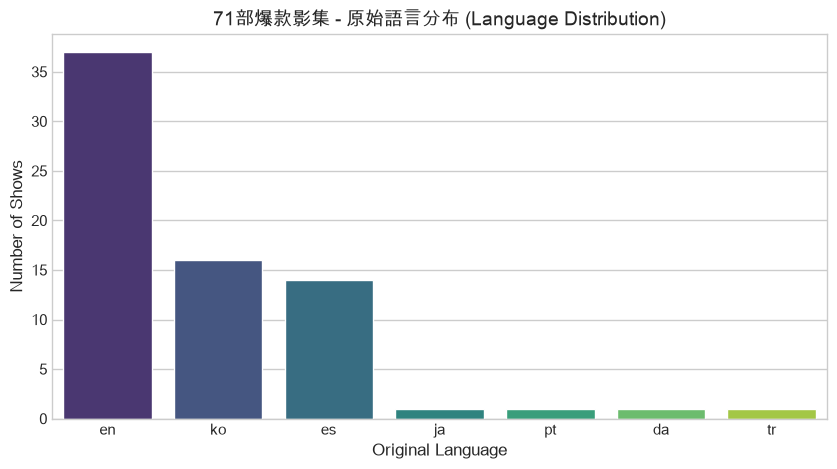

/var/folders/m3/mxn0108j41x3cp5x3trm41fh0000gn/T/ipykernel_4816/458829596.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


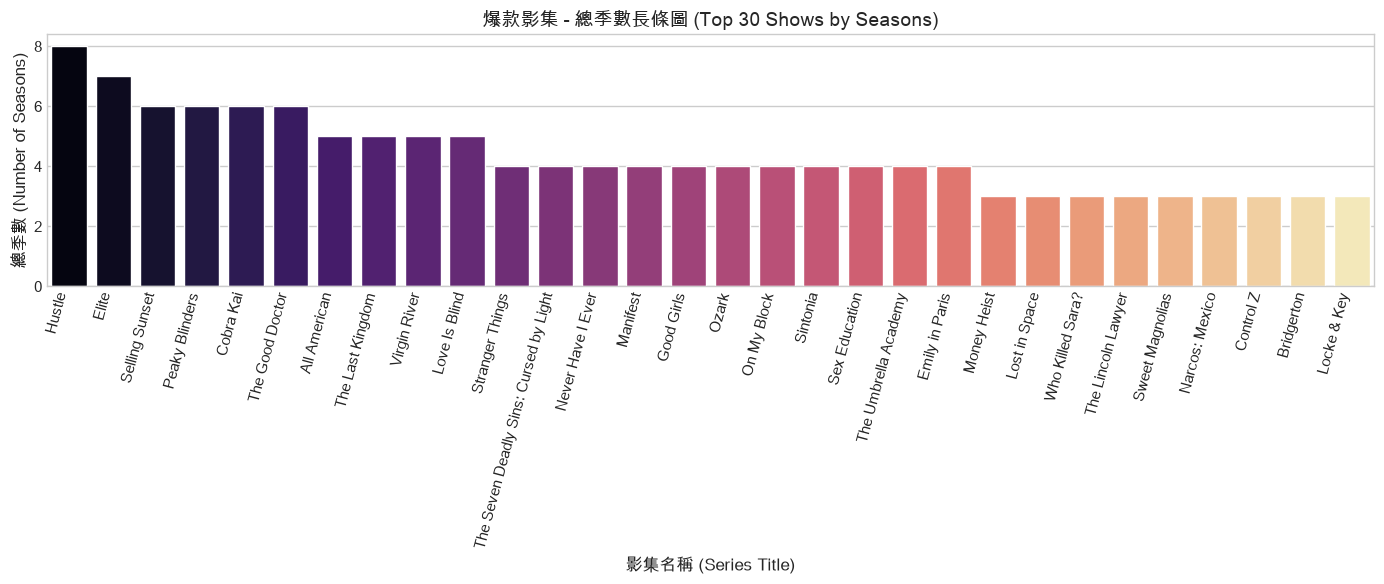

/var/folders/m3/mxn0108j41x3cp5x3trm41fh0000gn/T/ipykernel_4816/458829596.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


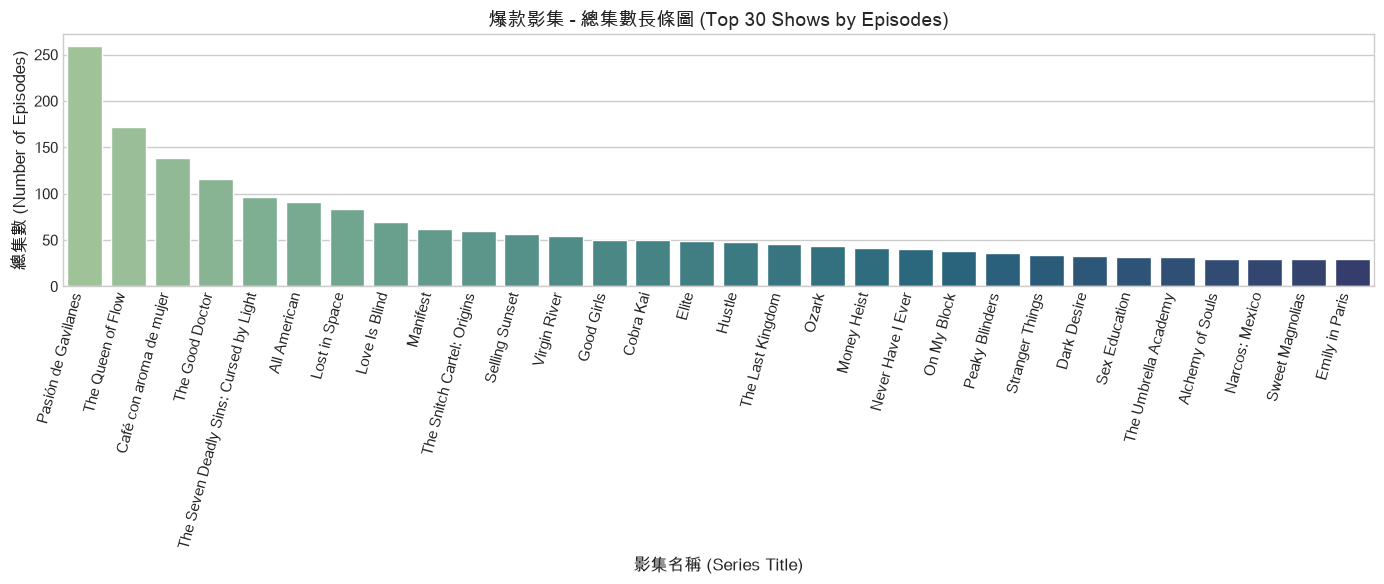

In [70]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ==========================================
# 1. 擴充想關注的特徵欄位（輸出多一點資料）
# ==========================================
selected_features = [
    "Hit_rank",  # PCA 排名
    "Hit_score",  # PCA 分數
    "netflix_title",  # 影集名稱
    "TMDb_raw_original_language",  # 原始語言 (例如: en, ko, es)
    "TMDb_raw_origin_country",  # 製作國家 (例如: US, KR, ES)
    "TMDb_raw_number_of_seasons",  # 總季數
    "TMDb_raw_number_of_episodes",  # 總集數
    "TMDb_raw_vote_average",  # (建議新增) TMDb 觀眾評分
    "TMDb_raw_popularity",  # (建議新增) TMDb 熱度指標
    "TMDb_raw_genres",  # 類型
]

# 確保欄位存在
available_columns = [
    col for col in selected_features if col in df_ranked_all_features.columns
]
df_brief = df_ranked_all_features[available_columns].copy()

# ==========================================
# 2. 在最後一欄加入「平均值」：平均每季集數
# ==========================================
df_brief["Avg_episodes_per_season"] = (
    df_brief["TMDb_raw_number_of_episodes"] / df_brief["TMDb_raw_number_of_seasons"]
).round(1)

# ==========================================
# 3. 輸出完整資料與統計總表
# ==========================================
# 設定 pandas 顯示所有列與欄，方便在 Notebook 中查看全貌
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("--- 【前 10 筆資料預覽】 ---")
display(df_brief.head(10))

# 建立包含「最末列平均值」的完整表格 (為不影響原始資料排序，使用新變數儲存)
df_with_summary = df_brief.copy()

# 計算數值欄位的平均值
mean_values = df_brief[
    [
        "Hit_score",
        "TMDb_raw_number_of_seasons",
        "TMDb_raw_number_of_episodes",
        "Avg_episodes_per_season",
    ]
].mean()

# 建立平均值的那一列資料
summary_row = pd.Series(
    {
        "Hit_rank": "-",
        "Hit_score": round(mean_values["Hit_score"], 2),
        "netflix_title": "【全體 71 部平均值】",
        "TMDb_raw_original_language": "-",
        "TMDb_raw_origin_country": "-",
        "TMDb_raw_number_of_seasons": round(
            mean_values["TMDb_raw_number_of_seasons"], 1
        ),
        "TMDb_raw_number_of_episodes": round(
            mean_values["TMDb_raw_number_of_episodes"], 1
        ),
        "TMDb_raw_genres": "-",
        "Avg_episodes_per_season": round(mean_values["Avg_episodes_per_season"], 1),
    }
)

# 附加到表格最後方
df_with_summary = pd.concat(
    [df_with_summary, pd.DataFrame([summary_row])], ignore_index=True
)

# 匯出成 CSV 檔案
output_brief_path = "netflix/data/hit_shows_features_with_averages.csv"
df_with_summary.to_csv(output_brief_path, index=False, encoding="utf-8-sig")
print(f"\n完整特徵表（含平均值）已匯出至：{output_brief_path}")

# ==========================================
# 4. 繪製視覺化圖表：語言、總季數、總集數長條圖
# ==========================================
sns.set_style("whitegrid")
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "Arial Unicode MS",
]  # 確保中文標題正確顯示

# 圖一：原始語言分布圖
plt.figure(figsize=(10, 5))
language_counts = df_brief["TMDb_raw_original_language"].value_counts()
sns.barplot(x=language_counts.index, y=language_counts.values, palette="viridis")
plt.title("71部爆款影集 - 原始語言分布 (Language Distribution)", fontsize=14)
plt.xlabel("Original Language", fontsize=12)
plt.ylabel("Number of Shows", fontsize=12)
plt.show()

# 圖二：總季數長條圖 (依季數由高到低排序，顯示前 25 名或全部)
plt.figure(figsize=(14, 6))
df_seasons_sorted = df_brief.sort_values(
    by="TMDb_raw_number_of_seasons", ascending=False
)
sns.barplot(
    data=df_seasons_sorted.head(30),  # 若想顯示全部 71 部，請移除 .head(30)
    x="netflix_title",
    y="TMDb_raw_number_of_seasons",
    palette="magma",
)
plt.title("爆款影集 - 總季數長條圖 (Top 30 Shows by Seasons)", fontsize=14)
plt.xlabel("影集名稱 (Series Title)", fontsize=12)
plt.ylabel("總季數 (Number of Seasons)", fontsize=12)
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

# 圖三：總集數長條圖 (依集數由高到低排序)
plt.figure(figsize=(14, 6))
df_episodes_sorted = df_brief.sort_values(
    by="TMDb_raw_number_of_episodes", ascending=False
)
sns.barplot(
    data=df_episodes_sorted.head(30),  # 若想顯示全部 71 部，請移除 .head(30)
    x="netflix_title",
    y="TMDb_raw_number_of_episodes",
    palette="crest",
)
plt.title("爆款影集 - 總集數長條圖 (Top 30 Shows by Episodes)", fontsize=14)
plt.xlabel("影集名稱 (Series Title)", fontsize=12)
plt.ylabel("總集數 (Number of Episodes)", fontsize=12)
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

## our analysis
？？

## our analysis
？？

## our analysis
？？

## our analysis
？？